## Columns to be removed from training/validation

In [1]:
disqualified_columns = ["tls_joint_isoitu_policy_crt_count", "rdap_time_from_last_change", "lex_www_flag"]         

# New problem features identified by Filip
disqualified_columns += ["lex_tld_abuse_score", "tls_leaf_cert_validity_len", "rdap_domain_active_time",
                         "tls_root_authority_hash",  "lex_tld_len", "tls_critical_extensions",
                         "tls_percentage_crt_with_policies"
                        ]         

# Dataset preparation

In [2]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

from pyarrow import Table
from pandas import DataFrame, api, Int64Dtype
from pandas.core.dtypes import common as com
import sys
sys.path.append('..')
from utils.preprocess import NDF

def cast_timestamp(df: DataFrame):
    """
    Cast timestamp fields to seconds since epoch.
    """
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()  # This converts timedelta to float (seconds)
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9  # Converts datetime64 to Unix timestamp (seconds)

    return df


def union_tables(tables: [pa.Table]) -> pa.Table:
    union_table = tables[0]
    for table in tables[1:]:
        right_not_in_union = union_table.join(right_table=table, keys='domain_name', join_type='right anti',
                                              coalesce_keys=True, use_threads=True)
        union_table = pa.concat_tables([union_table, right_not_in_union])
    return union_table

##################################
# EDIT to specify the model name #
##################################
model_name = "phishing_lgbm_model_nonndf"     
##################################

# #############################################################
# EDIT this to specify benign / malicious datasets to use     #
# #############################################################
benign_dataset_filenames = [
    '../feature-extraction/floor/benign_2312.parquet',
    '../feature-extraction/floor/umbrella_benign_FINISHED.parquet'
]
malicious_dataset_filenames = [
    #'../feature-extraction/floor/phishing_final_2024.parquet',
    #'../feature-extraction/floor/phishing_4.parquet',
    '../feature-extraction/floor/phishing_2406_strict.parquet',
]
# #############################################################
# EDIT this for to set appropriate labels (malware, dga, ...) #
# #############################################################
benign_label = "benign"
malicious_label = "phishing"
# #############################################################

# Unify malicious datasets and benign datasets
schema = (pq.read_table(malicious_dataset_filenames[0])).schema # Use the schema from the first malicious filename
benign_tables = [pq.read_table(filename).cast(schema) for filename in benign_dataset_filenames]

malicious_tables = [pq.read_table(filename).cast(schema) for filename in malicious_dataset_filenames]
malicious = union_tables(malicious_tables)
benign = union_tables(benign_tables)

# Convert pyarrow tables to pandas dataframes
df_benign = benign.to_pandas()
df_malicious = malicious.to_pandas()

# Set appropriate labels
df_benign["label"] = benign_label
df_malicious["label"] = malicious_label

# Merge the dataframes together
df = merged_df = pd.concat([df_benign, df_malicious], ignore_index=True)
class_map = {benign_label: 0, malicious_label: 1}

# Drop the domain name column
df.drop('domain_name', axis=1, inplace=True)

# Cast timestamps
df = cast_timestamp(df)

# Handle NaNs
df.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df.columns:
        df.drop(column, axis=1, inplace=True)

df

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


,label,dns_has_dnskey,dns_A_count,dns_AAAA_count,dns_MX_count,dns_NS_count,dns_TXT_count,dns_SOA_count,dns_CNAME_count,dns_zone_level,...,rdap_ip_v4_count,rdap_ip_v6_count,rdap_ip_shortest_v4_prefix_len,rdap_ip_longest_v4_prefix_len,rdap_ip_shortest_v6_prefix_len,rdap_ip_longest_v6_prefix_len,rdap_ip_avg_admin_name_len,rdap_ip_avg_admin_name_entropy,rdap_ip_avg_admin_email_len,rdap_ip_avg_admin_email_entropy
0,benign,0.0,0,0,0,0,0,0,1,0,...,1,0,19,19,0,0,15.000000,0.221549,0.000000,0.000000
1,benign,0.0,0,0,0,0,0,0,1,0,...,1,0,19,19,0,0,15.000000,0.221549,0.000000,0.000000
2,benign,1.0,1,1,1,4,2,1,0,0,...,7,6,17,24,48,48,11.384615,0.287974,3.538462,0.023059
3,benign,0.0,1,0,0,0,0,0,0,0,...,1,0,16,16,0,0,14.000000,0.231138,0.000000,0.000000
4,benign,0.0,1,0,0,0,0,0,0,0,...,1,0,16,16,0,0,14.000000,0.231138,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980744,phishing,0.0,1,0,0,2,0,1,0,0,...,17,2,13,16,22,22,6.210526,0.371952,23.894737,0.142238
980745,phishing,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000
980746,phishing,0.0,1,0,0,0,0,0,0,0,...,1,0,13,13,0,0,10.000000,0.292193,23.000000,0.157442
980747,phishing,0.0,1,1,0,0,2,0,0,0,...,1,1,21,21,48,48,10.000000,0.292193,23.000000,0.157442


In [3]:
# Convert the unique feature names to a list
#feature_names_list = ndf_dataset['feature_names'].unique().tolist()

# Print each feature name individually
#for feature in feature_names_list:
#    print(feature)


# Model validation function

In [4]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, log_loss, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from kneed import KneeLocator

# Helpers
from kneed import KneeLocator

def plot_metric(metric):
    plt.rcParams["figure.dpi"] = 300
    
    # Plot metric curves
    plt.plot(x_axis, results['training'][metric], label='Training set')
    plt.plot(x_axis, results['valid_1'][metric], label='Testing set')
    
    # Detect elbow using Kneedle algorithm
    kn = KneeLocator(x_axis, results['valid_1'][metric], curve='convex', direction='decreasing')
    if kn.knee:
        plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red', label='Elbow at tree ' + str(kn.knee))
    
    plt.legend()
    mnames = {'error': 'Classification Error', 'binary_logloss': 'Log Loss', 'auc': 'AUC'}
    mname = mnames.get(metric, metric)  # Return the metric itself if it's not in the dictionary
    plt.ylabel(mname)
    plt.xlabel('Number of trees')
    plt.title('LightGBM ' + mname)
    plt.show()

    
# Tuning - graphs
def DisplayTuningGraph(scores):
    from numpy import array
    from numpy.ma import masked_array

    col_names = ['mean_train_score', 'mean_test_score']
    means_df = scores[col_names]
    ax = means_df.plot(kind='line', grid=True)

    from matplotlib import pyplot as plt
    plt.rcParams["figure.figsize"] = [12, 12]
    plt.rcParams["figure.autolayout"] = True

    plt.rcParams["figure.dpi"] = 300

    max_ids = means_df.idxmax(axis=0)

    for i in range(len(max_ids)):
        for col_name in col_names:
            value = means_df[col_name][max_ids[i]]
            id = max_ids[i]

            color = 'r' if max_ids[i] == max_ids['mean_test_score'] else 'grey'

            ax.scatter([id], [value],
                      marker='o',
                      color=color,
                      label='point',)

            ax.annotate(str(round(value, 3))+"_ID="+str(id),
                        (id, value),
                        xytext=(id+3, value))
    print(scores)

def ValidateModel_advanced(X_test, y_test, model): 
    y_pred = model.predict(X_test)
    
    # Classification report
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    tn, fp, fn, tp = cm.ravel()
    print("Confusion Matrix:")
    print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

    # Plotting ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Model-specific evaluations
    if isinstance(model, (XGBClassifier, LGBMClassifier)):
        
        if isinstance(model, (XGBClassifier)):
            results = model.evals_result()
        elif isinstance(model, (LGBMClassifier)):
            results = model.evals_result_

        training_key = 'training' if isinstance(model, LGBMClassifier) else 'validation_0'
        validation_key = 'valid_1' if isinstance(model, LGBMClassifier) else 'validation_1'
        
        print("Training metrics:", results[training_key].keys())
        print("Validation metrics:", results[validation_key].keys())

        trees = len(results[validation_key]['binary_logloss']) if isinstance(model, LGBMClassifier) else len(results[validation_key]['logloss'])
        x_axis = range(0, trees)

        def plot_metric(metric):
            plt.rcParams["figure.dpi"] = 300

            # Plot metric curves
            plt.plot(x_axis, results[training_key][metric], label='Training set')
            plt.plot(x_axis, results[validation_key][metric], label='Validation set')

            # Detect elbow using Kneedle algorithm
            kn = KneeLocator(x_axis, results[validation_key][metric], curve='convex', direction='decreasing')
            if kn.knee:
                plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red', label='Elbow at tree ' + str(kn.knee))

            plt.legend()
            mnames = {'binary_logloss': 'Log Loss', 'auc': 'AUC'}
            mname = mnames.get(metric, metric)
            plt.ylabel(mname)
            plt.xlabel('Number of trees')
            plt.title(f'{type(model).__name__} {mname}')
            plt.show()

        if isinstance(model, LGBMClassifier):
            plot_metric('binary_logloss')
        elif isinstance(model, XGBClassifier):
            plot_metric('logloss')
            
        plot_metric('auc')
        
    elif isinstance(model, (RandomForestClassifier, AdaBoostClassifier)):
        # For RandomForest and AdaBoost, additional model-specific evaluations can be added here
        pass
    
    # Display the confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)  # Compute confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)  # Create display object
    disp.plot(cmap=plt.cm.Blues)  # Plot confusion matrix
    plt.show()  # Show the plot

# LightGBM

In [5]:
from sklearn.model_selection import train_test_split

labels = df['label'].apply(lambda x: class_map[x]) # y vector
features = df.drop('label', axis=1).copy() # X matrix

X_train, X_test, Y_train, Y_test = train_test_split(
  features,
  labels,
  test_size=0.2,
  random_state=42,
  shuffle=True, 
  stratify=labels
)

## LightGBM model Training

In [6]:
import joblib
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# LightGBM parameters
params = {
    "objective": "binary",  # binary classification
    "boosting_type": "gbdt",  # Gradient Boosting Decision Tree
    "n_estimators": 220, # Number of boosted trees to fit, equivalent to number of boosting iterations
    "num_leaves": 9,
    "max_depth": 8,
    "learning_rate": 0.07,
    "objective": "binary",
    "min_child_samples": 20,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 0.3,
    "scale_pos_weight": 0.01, # Positive class weight
    "subsample_for_bin": 210000,
    "random_state": 42
}

model = lgb.LGBMClassifier(**params, metric=['error', 'binary_logloss', 'auc'])

# at last, train the model
eval_set = [(X_train, Y_train), (X_test, Y_test)]
_ = model.fit(X_train, Y_train, eval_set=eval_set)

# Save the model to a file
joblib.dump(model, 'models/' + model_name + '.joblib')

[LightGBM] [Info] Number of positive: 131540, number of negative: 653059
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.085844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15668
[LightGBM] [Info] Number of data points in the train set: 784599, number of used features: 166
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.167653 -> initscore=-1.602356
[LightGBM] [Info] Start training from score -1.602356


['models/phishing_lgbm_model_nonndf.joblib']

## LightGBM model Validation

              precision    recall  f1-score   support

           0     0.9313    0.9999    0.9644    163265
           1     0.9994    0.6338    0.7757     32885

    accuracy                         0.9385    196150
   macro avg     0.9653    0.8169    0.8700    196150
weighted avg     0.9427    0.9385    0.9328    196150

Confusion Matrix:
TN: 163252 FP: 13 FN: 12042 TP: 20843


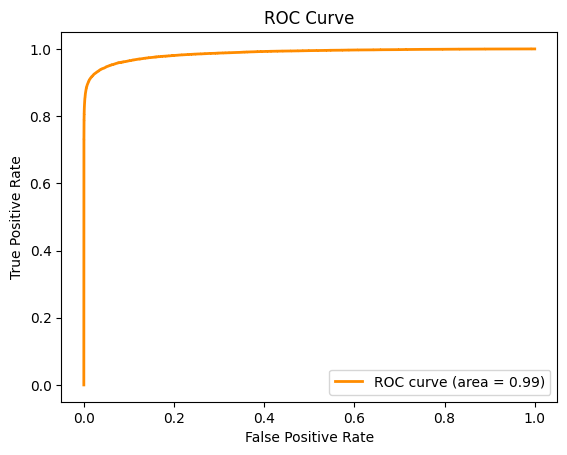

Training metrics: odict_keys(['binary_logloss', 'auc'])
Validation metrics: odict_keys(['binary_logloss', 'auc'])


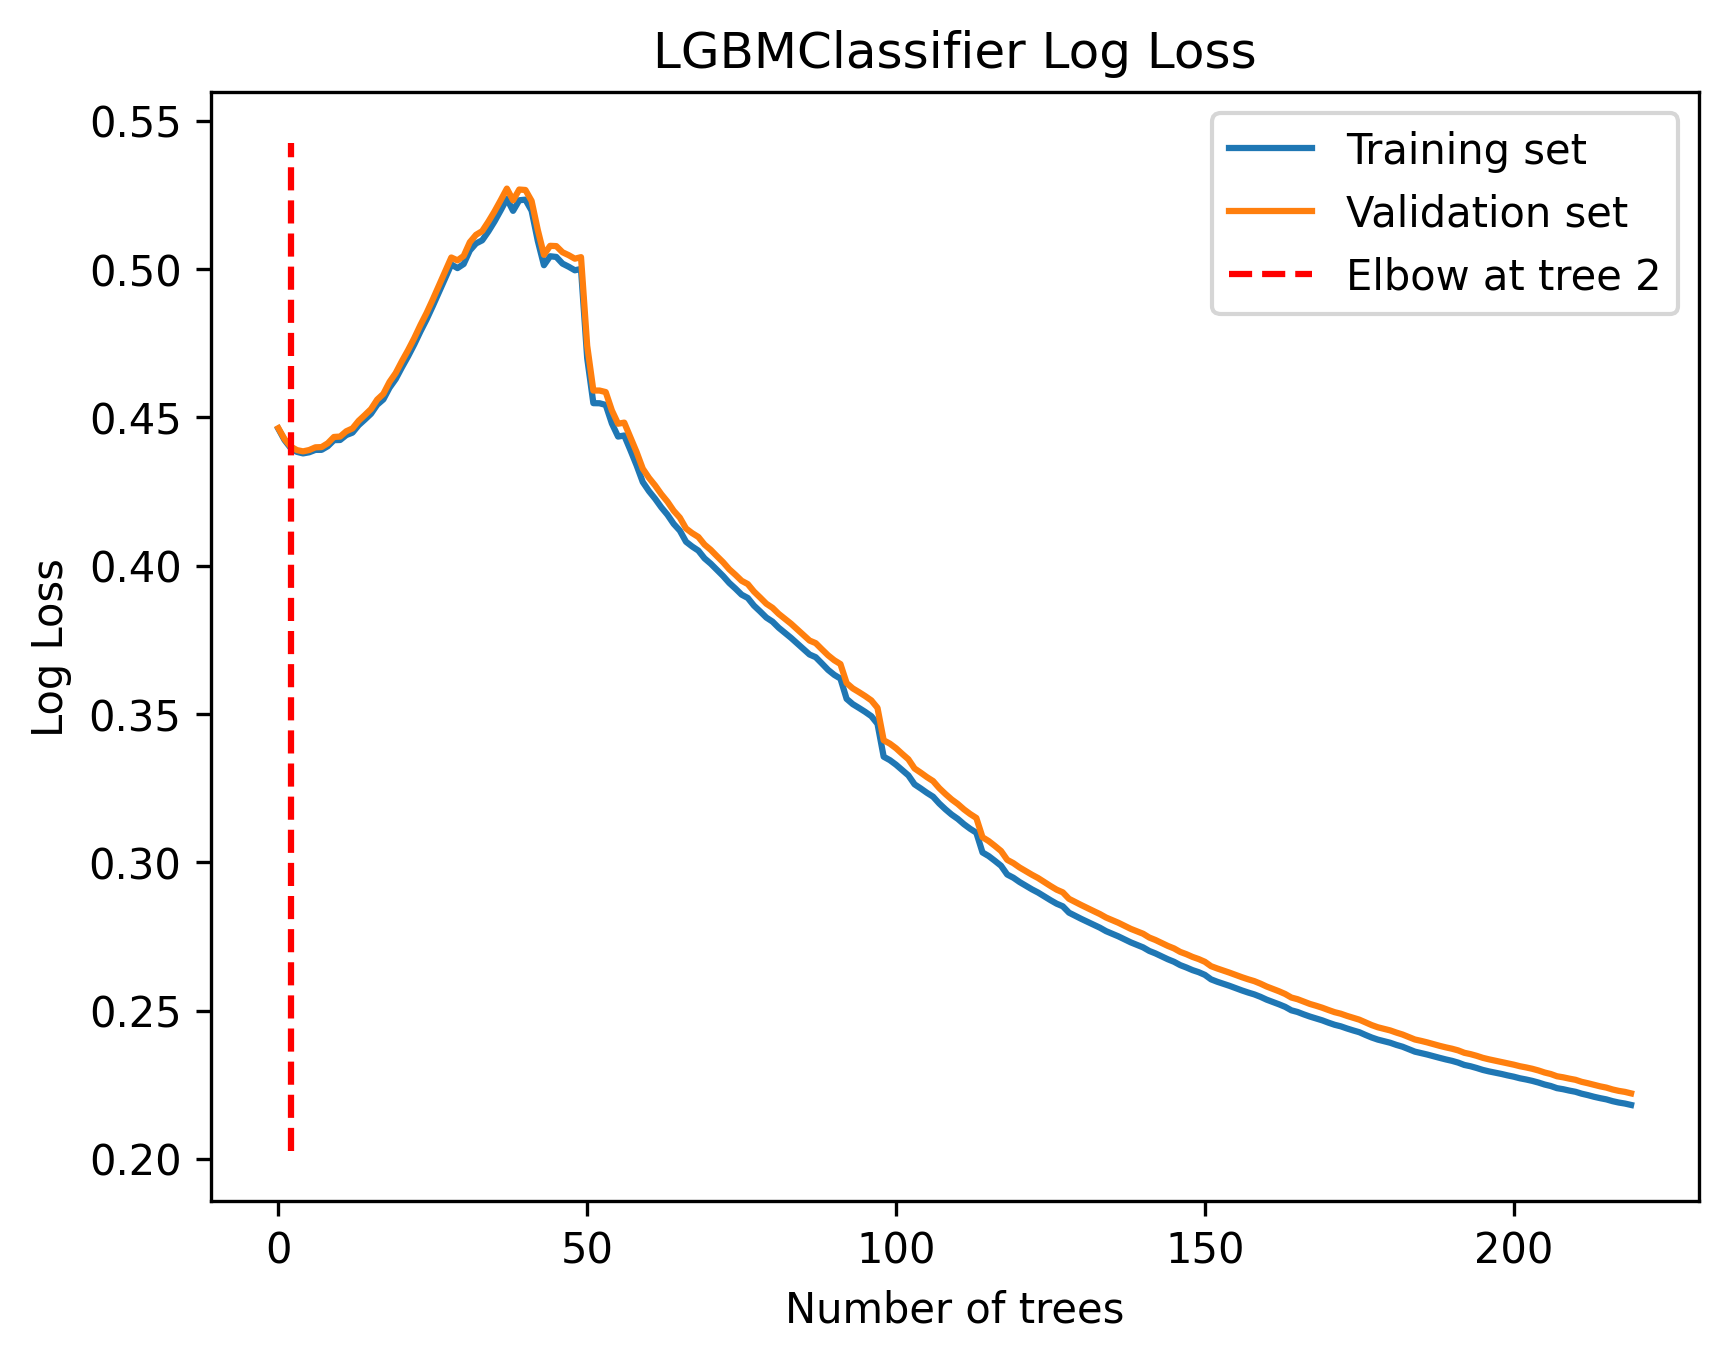

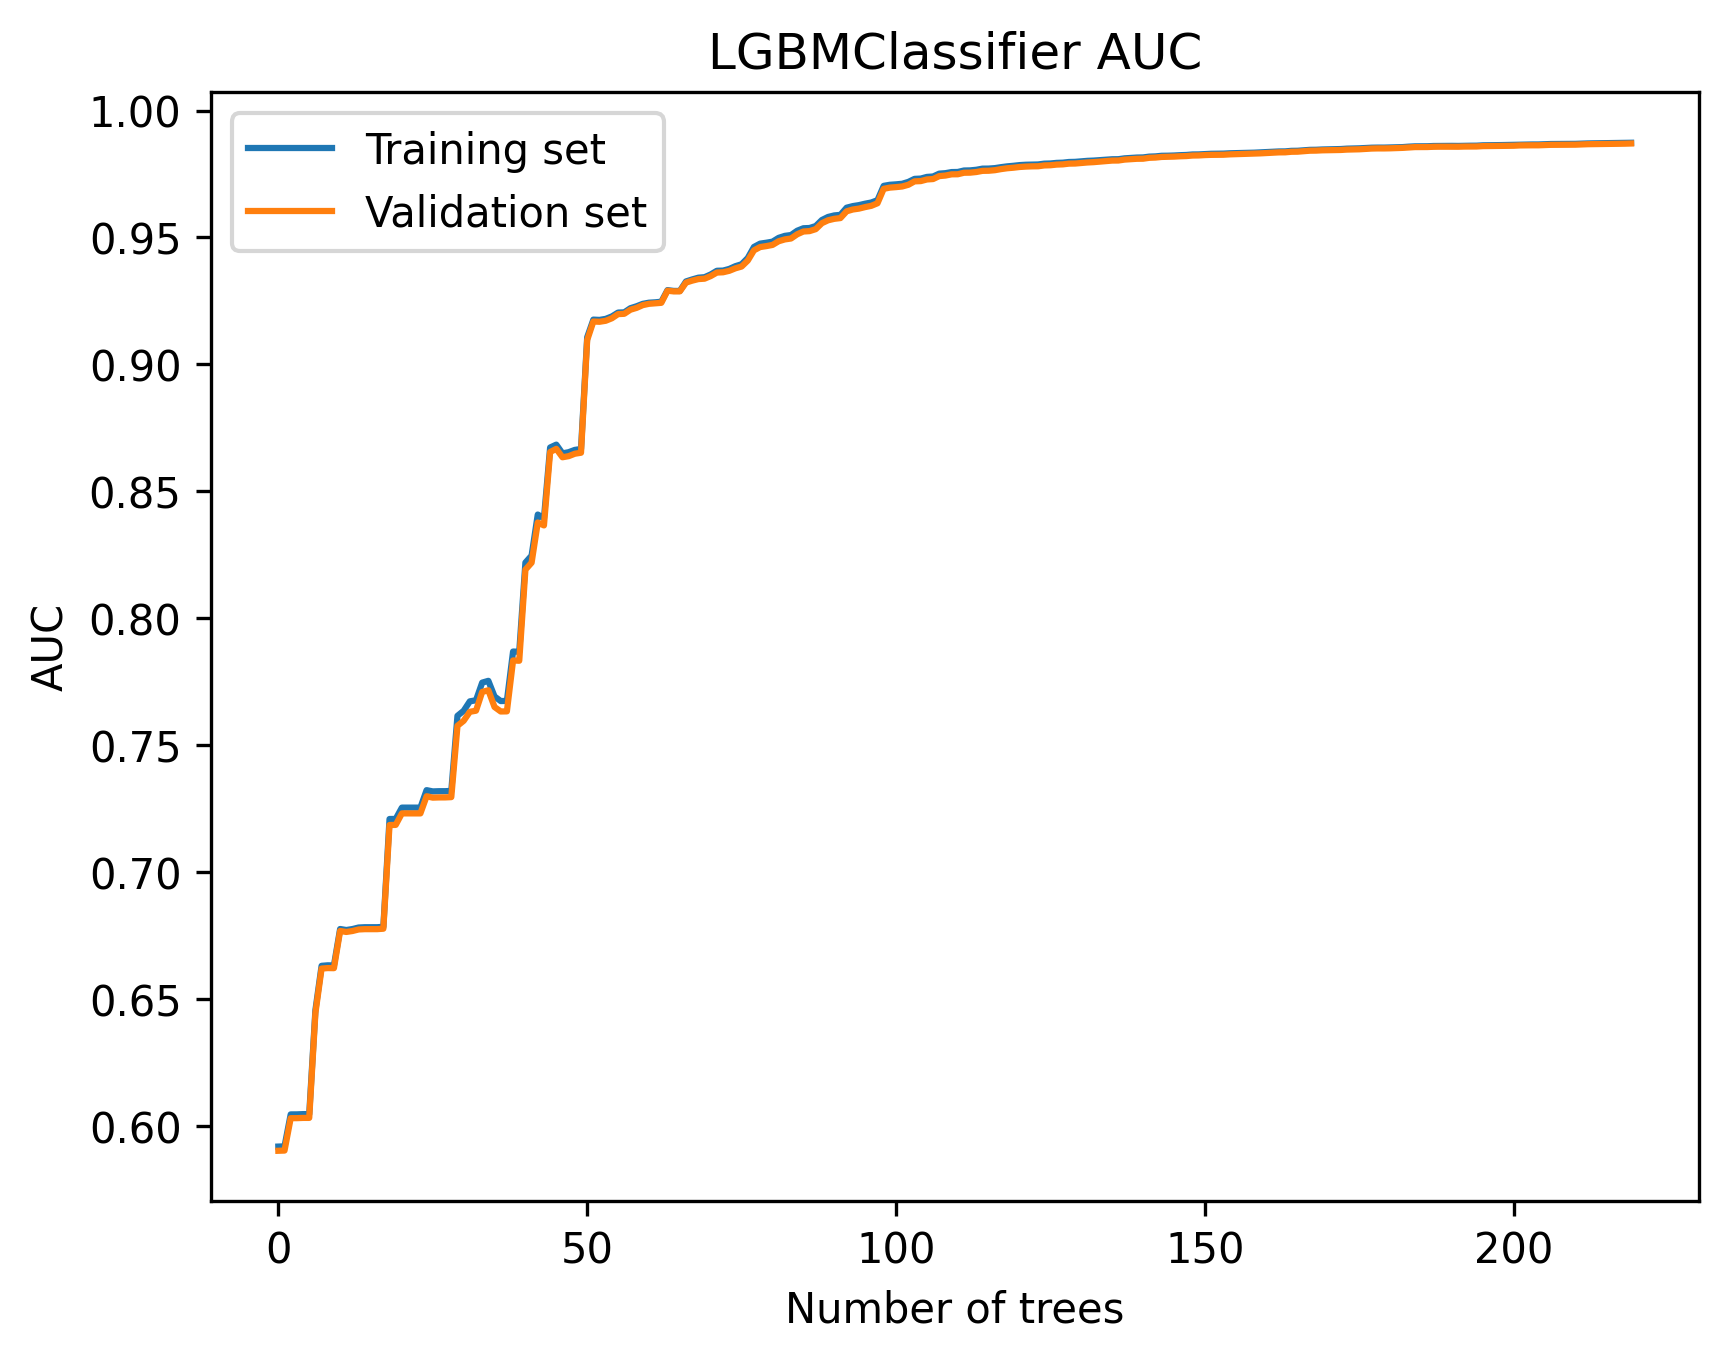

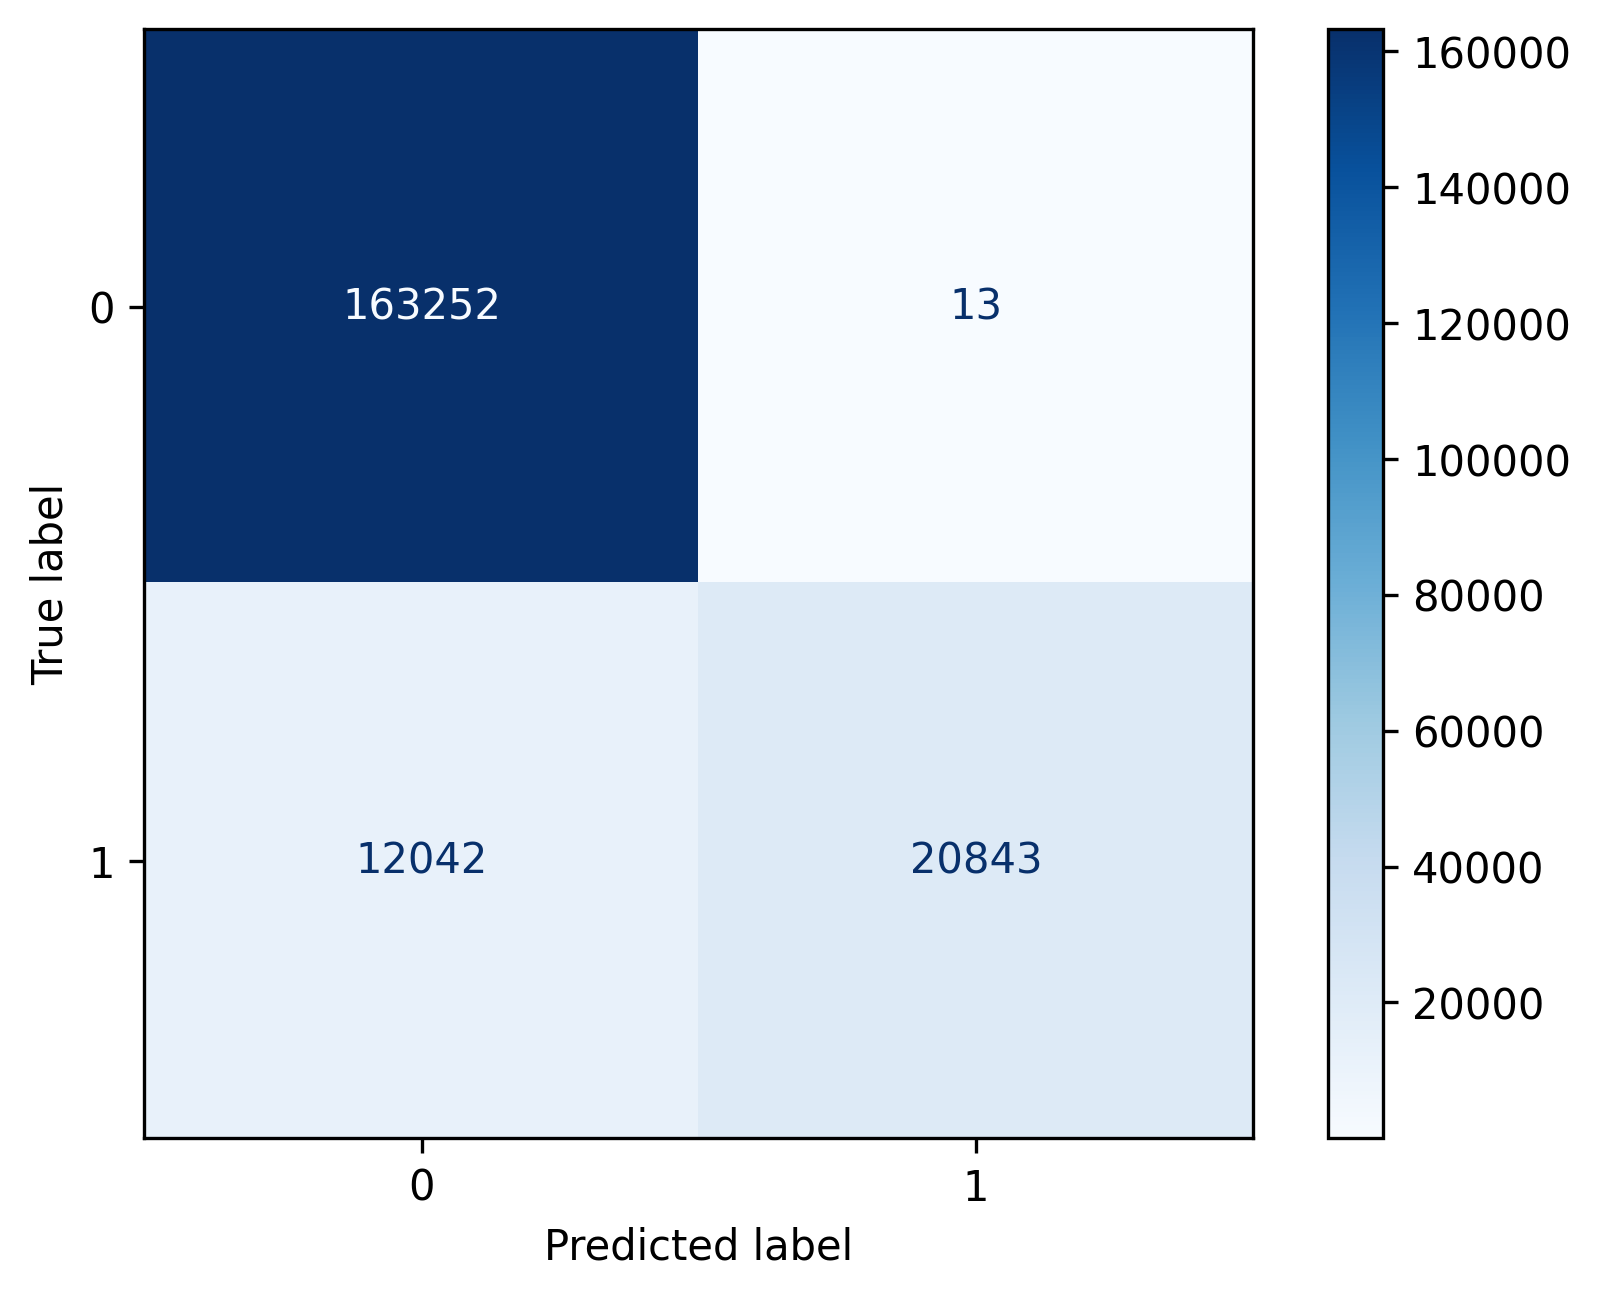

In [7]:
ValidateModel_advanced(X_test, Y_test, model)

## LightGBM model Tuning

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, log_loss

def FETA_Score(estimator, X, y):
    # Getting predictions
    y_pred = estimator.predict(X)
    y_pred_proba = estimator.predict_proba(X)
    
    # Calculating precision
    precision = precision_score(y, y_pred)
    
    # Calculating recall
    recall = recall_score(y, y_pred)
    
    # Calculating F1-score
    f1 = f1_score(y, y_pred)
    
    # Calculating FPR
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # Calculating Log Loss
    logloss = log_loss(y, y_pred_proba)
    
    # Estimating overfitting
    train_score = estimator.score(X_train, y_train) 
    validation_score = estimator.score(X, y) 
    overfitting = train_score - validation_score
    
    # Assigning weights
    w_precision = 0.1     # Precision
    w_recall = 0.1        # Recall
    w_f1 = 0.6            # F1
    w_fpr = -0.0          # Negative because lower FPR is better
    w_logloss = -0.0      # Negative because lower log loss is better
    w_overfitting = -0.2  # Negative because lower overfitting is better
    
    #w_precision = 0.0     # Precision
    #w_recall = 0.5        # Recall
    #w_f1 = 0.5            # F1
    #w_fpr = -0.0          # Negative because lower FPR is better
    #w_logloss = -0.1      # Negative because lower log loss is better
    #w_overfitting = -0.0  # Negative because lower overfitting is better
    
    # Assigning weights
    #w_precision = 0.1     # Precision
    #w_recall = 0.1        # Recall
    #w_f1 = 0.4            # F1
    #w_fpr = -0.1          # Negative because lower FPR is better
    #w_logloss = -0.1      # Negative because lower log loss is better
    #w_overfitting = -0.5  # Negative because lower overfitting is better
    
    # Combining metrics with weights
    combined_score = (w_precision * precision + w_recall * recall + w_f1 * f1 + w_fpr * fpr + w_overfitting * overfitting)
    
    return combined_score


In [9]:
lgbm_tuning = False

if lgbm_tuning:
    import pandas as pd
    from sklearn.model_selection import GridSearchCV
    from sklearn.model_selection import StratifiedKFold
    from lightgbm import LGBMClassifier  # Updated import

    params = {
        "objective": "binary",  # binary classification
        "boosting_type": "gbdt",  # Gradient Boosting Decision Tree
        "n_estimators": 230, # Number of boosted trees to fit, equivalent to number of boosting iterations
        "num_leaves": 8,
        "max_depth": 10,
        "learning_rate": 0.04,
        "objective": "binary",
        "min_child_samples": 10,
        "colsample_bytree": 0.9,
        "reg_alpha": 0.15,
        "reg_lambda": 0.2,
        "scale_pos_weight": 0.01, # Positive class weight
        "subsample_for_bin": 240000,
        "random_state": 7,
    }


    clf = LGBMClassifier(**params)  # Updated classifier instantiation

    # this is your grid of parameters to search through, every combination will be tried
    grid = {
        "n_estimators": [600, 700, 800],
        "max_depth": [10, 12, 14, 16, 18],
        #"n_estimators": [897],
        #"num_leaves": [59],
        #"max_depth": [20],
        #"learning_rate": [0.11, 0.12, 0.13, 0.2],
        #'scale_pos_weight': [1.7, 1.8, 1.9],
        #"subsample": [0.1],
        #reg_lambda": [0.1],
        #'min_split_gain' : [0.0, 0.1, 0.2]
        #'subsample_for_bin': [215000, 220000, 230000, 240000],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)
    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=grid,
        #n_jobs=-1,
        cv=cv,
        #scoring='neg_log_loss',
        #scoring='f1',  # You can change this to another scoring method if needed
        scoring=FETA_Score,  # Custom metric
        verbose=3,
        return_train_score=True
    )

    grid_search.fit(X_train, Y_train)

    clf = grid_search.best_estimator_

    scores = pd.DataFrame(grid_search.cv_results_)
    col_names = ['mean_train_score', 'mean_test_score']

    scores = pd.DataFrame(grid_search.cv_results_)



In [10]:
a = ""
if lgbm_tuning:
    DisplayTuningGraph(scores)
    a = scores

a

''

# Test on another Validation dataset

Accuracy: 0.9415322580645161
Weighted Accuracy: 0.8355203619909501
Precision: 0.7470355731225297
Recall: 0.7
F1 Score: 0.722753346080306
False Positive Rate: 0.02895927601809955


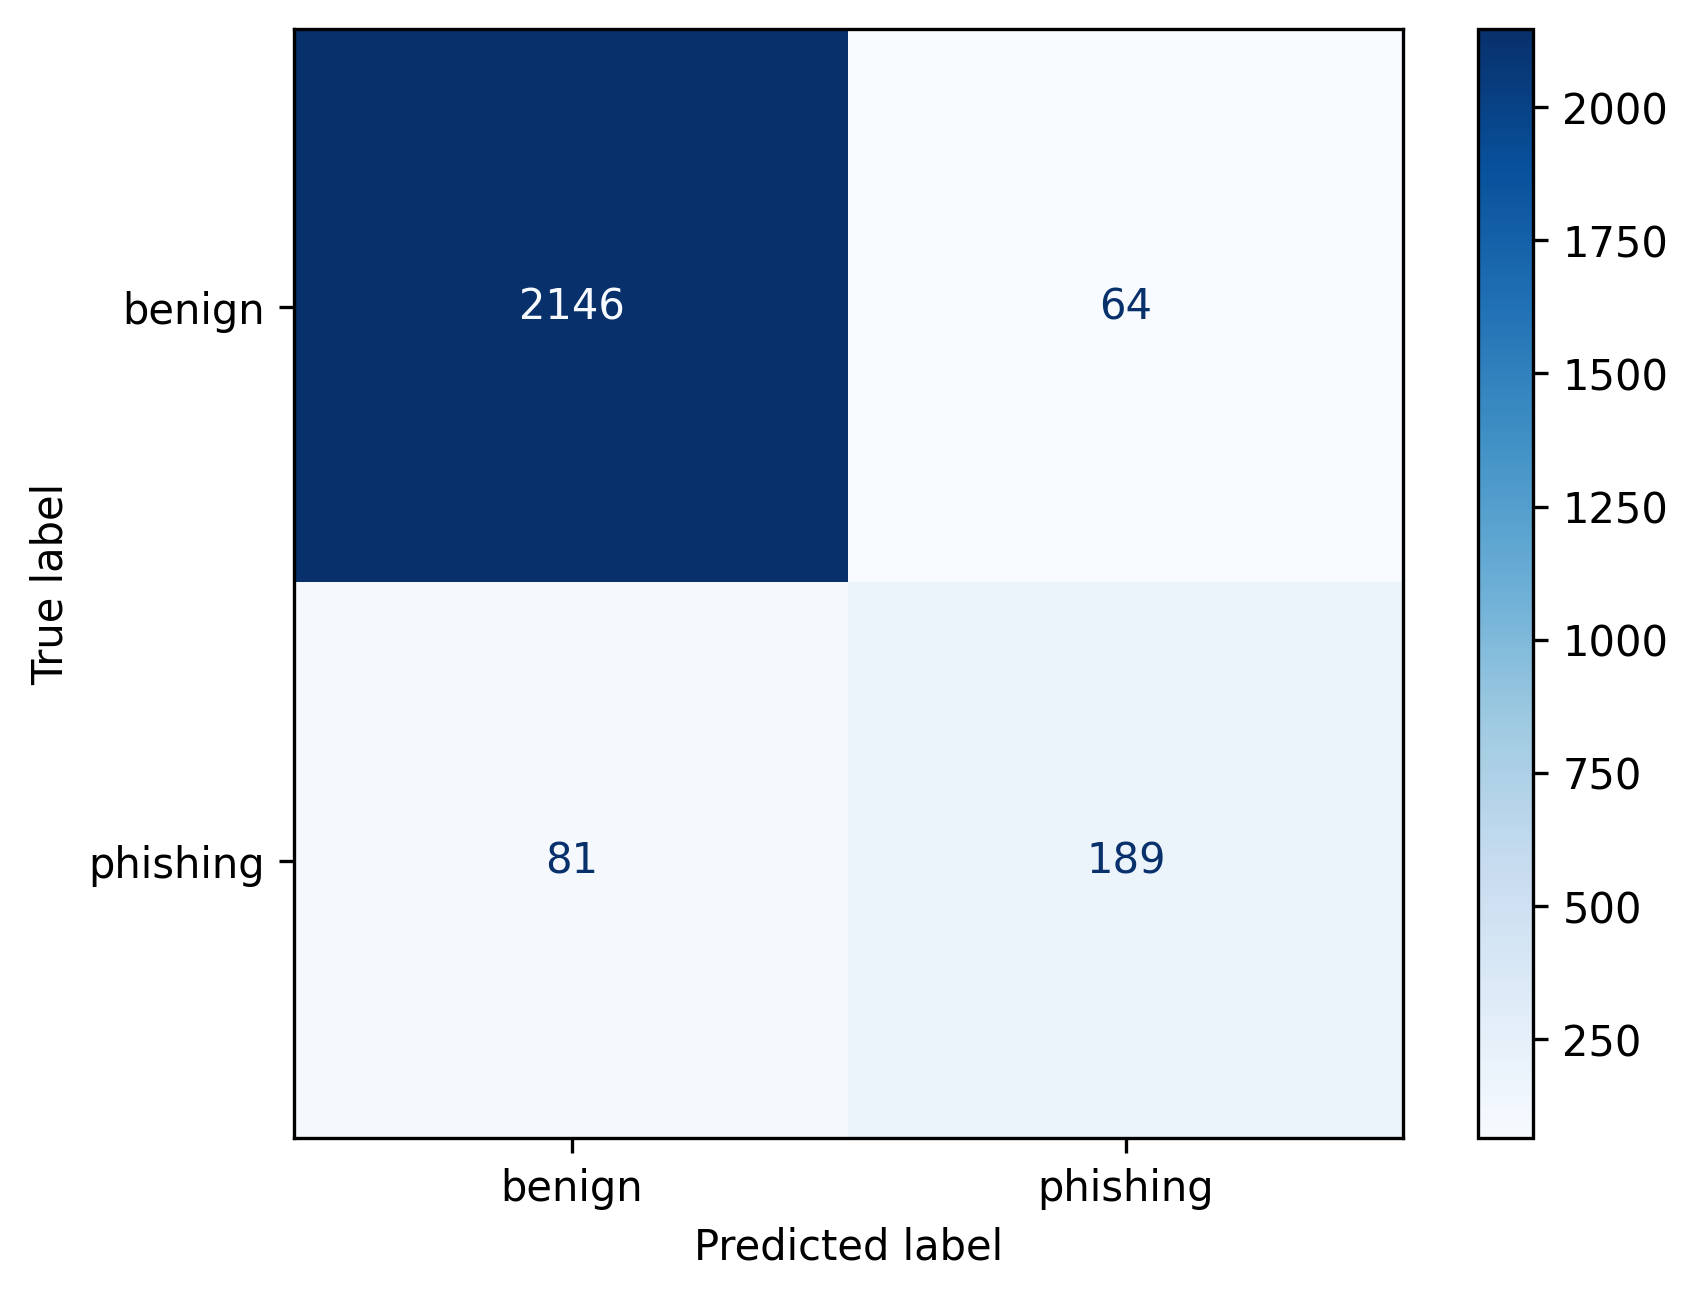

Misclassified domains: ['3793svxn.computer-mod-s.tech', 'plinkos-organization.gitbook.io', '0162xygl.computer-mod-s.tech', 'steamproxy-hk.imbastar.com', 'zurvan-24b-03.top', 'm.bi18.cc', 'fodi.caijimoyu.eu.org', '1456ubmz.computer-mod-s.tech', '1ict4apf8oom7qga94n31uwt9.trivialextrovertedarrangement.pro', 'livewalletconnect.blogspot.co.il', '9172mzgd.computer-mod-s.tech', 'sjsabb.com', 'a.a1d4ef5d.shop', 'bestbargain-4u.com', 'hp18.pages.dev', 'www.streamblasters.fans', 'novosibirsk.pr-volga.ru', '3653.mk', 'reviewholdreviewho.wixsite.com', 'www.magicbath.co.in', 'a.eiuyhrhfodj0d11.shop', 'zet.hlsvideocdn121.shop', 'lib.wenxian2.shop', 'www.rdmbox.com', 'loans837113.life', 'alexadam.sk', '2688tsay.computer-mod-s.tech', 'marutiminchem.com', 'heoo2.511110.xyz', 'helldivers.io', 'arbearssgrounds.wixsite.com', 'anjnis.com', 'cf.bmzk.link', 'fuorifrigo.com', 'esx1.qawsedrftgyhujik27.shop', 'namaskarmahra.com', 'aidboxes.com', 'zdy.yong96.link', 'a6-d9r.pages.dev', 'mswap.bbd.sh', 'upfupf.co

In [11]:
import pyarrow.parquet as pq
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
import shap
from pandas.core.dtypes import common as com
import numpy as np

def cast_timestamp(df: pd.DataFrame):
    """
    Cast timestamp fields to seconds since epoch.
    """
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()  # This converts timedelta to float (seconds)
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9  # Converts datetime64 to Unix timestamp (seconds)
    return df

# Load the validation dataset
validation_dataset_filename = '../testdata/validation_phishing.parquet'
df_validation = pq.read_table(validation_dataset_filename).to_pandas()

# Cast timestamps and handle NaNs
df_validation = cast_timestamp(df_validation)
df_validation.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df_validation.columns:
        df_validation.drop(column, axis=1, inplace=True)

# Map the labels
df_validation['label'] = df_validation['label'].map({'benign': 0, 'phishing': 1})

# Extract features and labels
X_val = df_validation.drop(['label', 'domain_name'], axis=1)
y_val = df_validation['label']

# Load the trained model
model = joblib.load('models/' + model_name + '.joblib')

# Make predictions
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
weighted_accuracy = (accuracy_score(y_val[y_val == 0], y_pred[y_val == 0]) + accuracy_score(y_val[y_val == 1], y_pred[y_val == 1])) / 2
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
false_positive_rate = fp / (fp + tn)

# Display metrics
print(f'Accuracy: {accuracy}')
print(f'Weighted Accuracy: {weighted_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'False Positive Rate: {false_positive_rate}')

# Display confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Identify misclassified domain names
misclassified = df_validation[y_val != y_pred]
misclassified_domains = misclassified['domain_name'].tolist()
print(f'Misclassified domains: {misclassified_domains}')

# Advanced tuning - Training on Training portion, Validation on Validation dataset

Rebuilt training split: X_train (784599, 166) Y_train 784599 X_test (196150, 166) Y_test 196150
Validation shapes: (2480, 166) 2480
Fitting 1 folds for each of 1 candidates, totalling 1 fits
[LightGBM] [Info] Number of positive: 131540, number of negative: 653059
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15655
[LightGBM] [Info] Number of data points in the train set: 784599, number of used features: 166
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.167653 -> initscore=-1.602356
[LightGBM] [Info] Start training from score -1.602356
[CV 1/1] END ..............., score=(train=0.784, test=0.749) total time=   8.4s
[LightGBM] [Info] Number of positive: 131810, number of negative: 655269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.0843

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
0,8.3662,0.0,0.0074,0.0,{},0.749,0.749,0.0,1,0.7839,0.7839,0.0


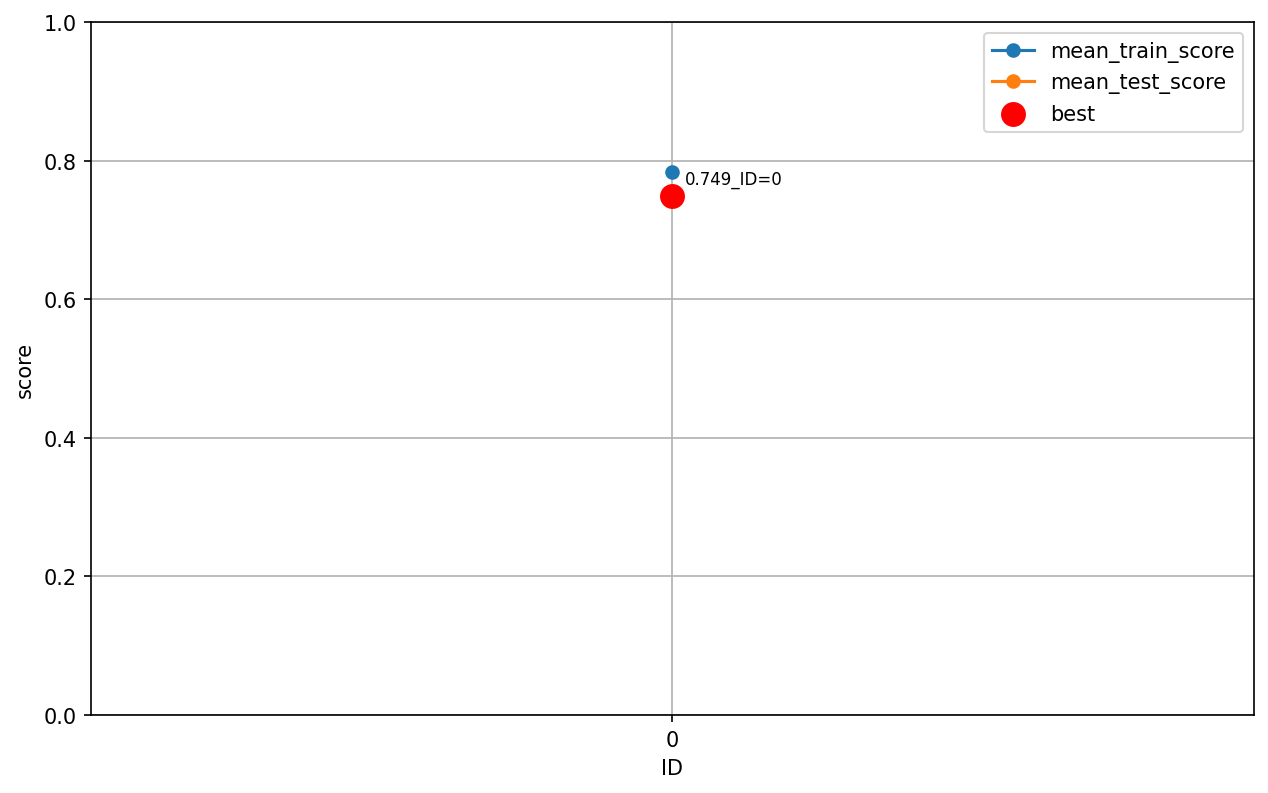

In [12]:
# ==========================
# Advanced tuning for LightGBM
# (train split + external validation parquet via PredefinedSplit)
# ==========================
advanced_lgbm_tuning = True

if advanced_lgbm_tuning:
    import pyarrow.parquet as pq
    import pyarrow as pa
    import pandas as pd
    import numpy as np
    import joblib
    from pandas.core.dtypes import common as com
    from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
    from lightgbm import LGBMClassifier

    # ----------------------
    # Helpers
    # ----------------------
    def cast_timestamp(df: pd.DataFrame):
        for col in df.columns:
            if com.is_timedelta64_dtype(df[col]):
                df[col] = df[col].dt.total_seconds()
            elif com.is_datetime64_any_dtype(df[col]):
                df[col] = df[col].astype(np.int64) // 10**9
        return df

    def union_tables(tables: [pa.Table]) -> pa.Table:
        union_table = tables[0]
        for table in tables[1:]:
            right_not_in_union = union_table.join(
                right_table=table, keys='domain_name', join_type='right anti',
                coalesce_keys=True, use_threads=True
            )
            union_table = pa.concat_tables([union_table, right_not_in_union])
        return union_table

    # If not defined upstream, set safe defaults
    try:
        disqualified_columns
    except NameError:
        disqualified_columns = []
    try:
        model_name
    except NameError:
        model_name = "phishing_lgbm_advanced"

    # ----------------------
    # 1) Build TRAIN split deterministically
    # ----------------------
    benign_dataset_filenames = [
        '../feature-extraction/floor/benign_2312.parquet',
        '../feature-extraction/floor/umbrella_benign_FINISHED.parquet'
    ]
    malicious_dataset_filenames = [
        '../feature-extraction/floor/phishing_2406_strict.parquet',
    ]
    benign_label = "benign"
    malicious_label = "phishing"
    class_map = {benign_label: 0, malicious_label: 1}

    schema = pq.read_table(malicious_dataset_filenames[0]).schema
    benign_tables = [pq.read_table(f).cast(schema) for f in benign_dataset_filenames]
    malicious_tables = [pq.read_table(f).cast(schema) for f in malicious_dataset_filenames]

    benign = union_tables(benign_tables)
    malicious = union_tables(malicious_tables)

    df_benign = benign.to_pandas()
    df_malicious = malicious.to_pandas()
    df_benign["label"] = benign_label
    df_malicious["label"] = malicious_label

    df_train_full = pd.concat([df_benign, df_malicious], ignore_index=True)

    if 'domain_name' in df_train_full.columns:
        df_train_full.drop(columns='domain_name', inplace=True)

    df_train_full = cast_timestamp(df_train_full)
    df_train_full.fillna(-1, inplace=True)

    for c in disqualified_columns:
        if c in df_train_full.columns:
            df_train_full.drop(columns=c, inplace=True)

    labels = df_train_full['label'].map(class_map).astype(int)
    features = df_train_full.drop(columns=['label'])

    X_train, X_test, Y_train, Y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42, shuffle=True, stratify=labels
    )
    print("Rebuilt training split:",
          "X_train", X_train.shape, "Y_train", len(Y_train),
          "X_test", X_test.shape,   "Y_test", len(Y_test))

    # ----------------------
    # 2) Load VALIDATION parquet and align columns
    # ----------------------
    validation_dataset_filename = '../testdata/validation_phishing.parquet'
    df_val = pq.read_table(validation_dataset_filename).to_pandas()

    for c in disqualified_columns:
        if c in df_val.columns:
            df_val.drop(columns=c, inplace=True)

    df_val = cast_timestamp(df_val)
    df_val.fillna(-1, inplace=True)

    label_map = {'benign': 0, 'phishing': 1}
    df_val['label_mapped'] = df_val['label'].map(label_map)
    unmapped = df_val['label_mapped'].isna().sum()
    if unmapped:
        raise ValueError(f"Validation has {unmapped} rows with unmapped labels. "
                         f"Check df_val['label'].value_counts().")

    df_val['label_mapped'] = df_val['label_mapped'].astype(int)

    desired_cols = list(X_train.columns)
    X_val = df_val.drop(columns=['label', 'label_mapped', 'domain_name'], errors='ignore')
    X_val = X_val.reindex(columns=desired_cols, fill_value=-1)
    y_val = df_val['label_mapped'].reset_index(drop=True)

    print("Validation shapes:", X_val.shape, len(y_val))

    # ----------------------
    # 3) Combine + PredefinedSplit (TRAIN vs external VALIDATION)
    # ----------------------
    X_combined = pd.concat(
        [X_train.reset_index(drop=True), X_val.reset_index(drop=True)],
        axis=0, ignore_index=True
    )
    y_combined = pd.concat(
        [Y_train.reset_index(drop=True), y_val.reset_index(drop=True)],
        axis=0, ignore_index=True
    )
    assert len(X_combined) == len(y_combined)

    # -1 marks training rows, 0 marks validation rows
    test_fold = np.r_[
        -1 * np.ones(len(X_train), dtype=int),
         0 * np.ones(len(X_val),   dtype=int)
    ]
    ps = PredefinedSplit(test_fold=test_fold)

    # ----------------------
    # 4) Grid search (fresh estimator)
    # ----------------------
    base_params = {
        "objective": "binary",  # binary classification
        "boosting_type": "gbdt",  # Gradient Boosting Decision Tree
        "n_estimators": 220, # Number of boosted trees to fit, equivalent to number of boosting iterations
        "num_leaves": 9,
        "max_depth": 8,
        "learning_rate": 0.07,
        "objective": "binary",
        "min_child_samples": 20,
        "colsample_bytree": 0.9,
        "reg_alpha": 0.1,
        "reg_lambda": 0.3,
        "scale_pos_weight": 0.01, # Positive class weight
        "subsample_for_bin": 210000,
        "random_state": 42,
        # If you have GPU build, uncomment the next line:
        # "device": "gpu",
    }
    estimator = LGBMClassifier(**base_params)

    grid = {
        # keep it tight; expand as needed
        #"num_leaves":   [6, 7, 8, 9],
        #"max_depth":   [6, 7, 8, 9],
        #"n_estimators": [210,220,230],
        #"max_depth": [8, 9, 10, 11],
        #"reg_lambda":   [0.0, 0.2, 0.3, 0.5],
        #"reg_alpha":    [0.0, 0.1, 0.15, 0.2],
        # You can also explore:
        # "learning_rate": [0.03, 0.05, 0.07],
        #"min_child_samples": [20, 21, 22, 23, 24, 25],
        #"subsample_for_bin": [180000, 190000, 200000, 210000,  250000],
        #"colsample_bytree": [0.9, 1.0],
        # "max_depth": [-1, 10, 16],
    }

    gs = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        cv=ps,
        scoring='f1',           # same as your XGB grid; swap if you prefer custom
        verbose=3,
        return_train_score=True,
        refit=True              # refit on all X_combined with best params
    )
    gs.fit(X_combined, y_combined)

    best = gs.best_estimator_
    joblib.dump(best, f'models/{model_name}_best_lgbm.joblib')

    print("Best parameters:", gs.best_params_)
    print("Best score:", gs.best_score_)

    scores = (
        pd.DataFrame(gs.cv_results_)
          .reset_index(drop=True)
          .round(4)
    )

# ----------------------
# Optional plotting helper (mirrors your DisplayTuningGraph2)
# ----------------------
def DisplayTuningGraph2_LGBM(scores, metric="mean_test_score"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    s = scores.copy().reset_index(drop=True)
    s["ID"] = np.arange(len(s))

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    ax.plot(s["ID"], s["mean_train_score"], marker="o", label="mean_train_score")
    ax.plot(s["ID"], s[metric],             marker="o", label=metric)

    for _, row in s.iterrows():
        ax.annotate(f"{row[metric]:.3f}_ID={row['ID']}",
                    (row["ID"], row[metric]),
                    xytext=(6, 6), textcoords="offset points", fontsize=8)

    best_idx = s[metric].idxmax()
    best_id  = int(s.loc[best_idx, "ID"])
    best_val = float(s.loc[best_idx, metric])
    ax.scatter([best_id], [best_val], color="red", s=120, zorder=5, label="best")

    ax.set_xlabel("ID")
    ax.set_ylabel("score")
    ax.set_xticks(s["ID"])
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend()

    param_cols = [c for c in s.columns if c.startswith("param_") or c == "n_estimators"]
    extra_cols = [c for c in ["rank_test_score", "mean_fit_time"] if c in s.columns]
    cols_to_show = ["ID"] + param_cols + ["mean_train_score", metric] + extra_cols
    print(s[cols_to_show].to_string(index=False))
    return fig, ax

display = ''
if advanced_lgbm_tuning:
    DisplayTuningGraph2_LGBM(scores)
    display = scores

display


# FP Debug

Mean of empty slice.
invalid value encountered in scalar divide


Accuracy: 0.6459430979978925
Weighted Accuracy: nan
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
False Positive Rate: 0.3540569020021075


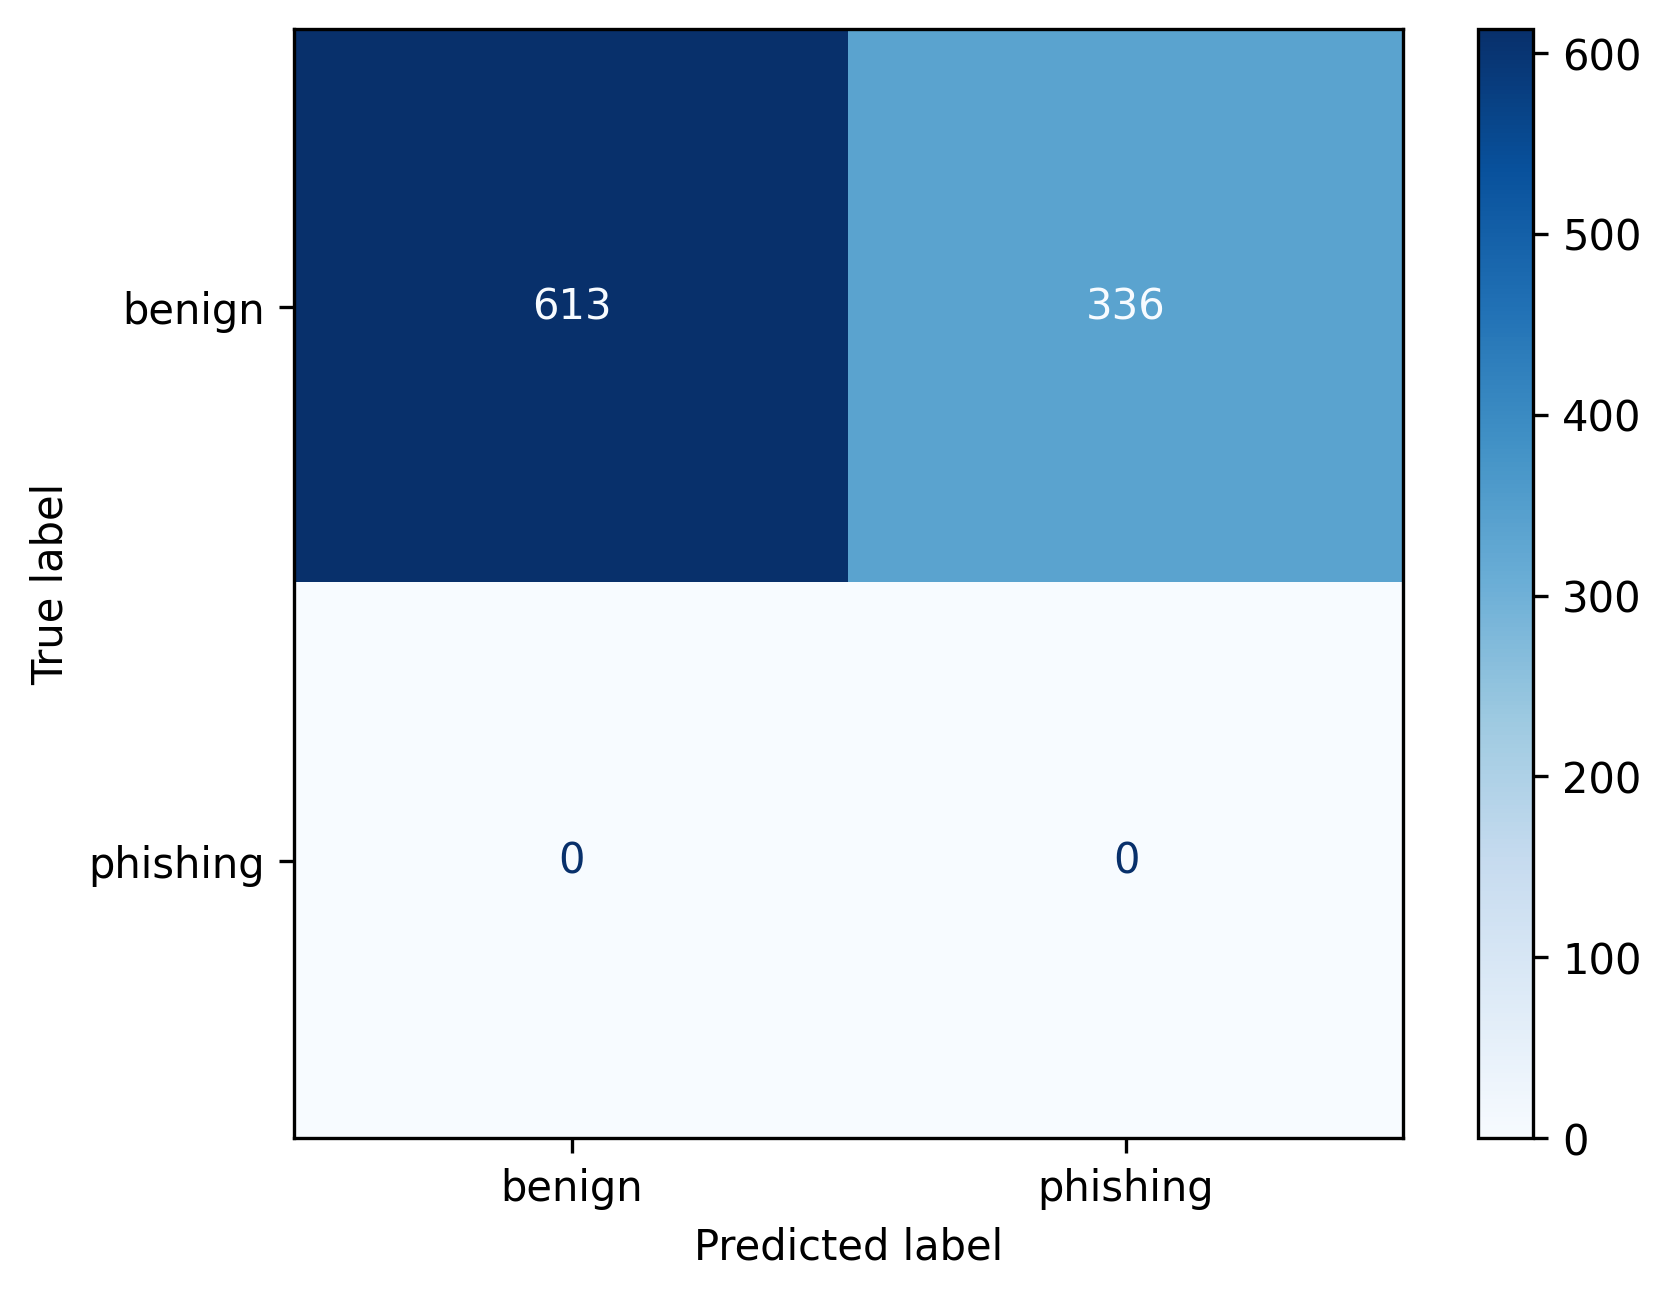

Misclassified domains: ['10bdmbet43.com', '123hdd.com', '123sss.net', '14pg2.com', '14pg8.com', '1x7bet.xyz', '2588989.com', '2aksestukul.pro', '42pg10.com', '53pgdd.com', '5671602.xyz', '599k11.com', '66llottery.org', '66uba.com', '72pgdd.com', '777boijogo.com', '95cemara777.com', '99tg9e.com', 'aa888.pw', 'aceh4dterbaik.pro', 'acenewshub.com', 'adzkialearningcenter.com', 'aethrascans.com', 'agen89pizza.com', 'agenqris.xyz', 'ahazzfundsllc.com', 'airbornerf.com', 'ajudanfounder88.com', 'alhawra-engg.com', 'amarfreelancer.com', 'ammo88resmi.com', 'ampseonetpedia33.com', 'aocreation.com', 'apispwo.com', 'aq777.xyz', 'arise-crossover.com', 'arkwild.fr', 'asco-tokai.com', 'asharmerac2.com', 'asset-arw.xyz', 'avdalgi-70.com', 'avgosu54.com', 'b1h2d.com', 'barnzmu.com', 'bc3pfp.com', 'bejo88rally.xyz', 'belutjpgo.com', 'big777pro9.com', 'bima-lucillatitus.net', 'bima-vikingvoyage.net', 'blg-10.com', 'bluesea-croatia.com', 'books-sciknowpub.com', 'bos01-n.com', 'bsbs-1642.com', 'bszb309.com'


Domain: 10bdmbet43.com


<Figure size 3600x900 with 0 Axes>

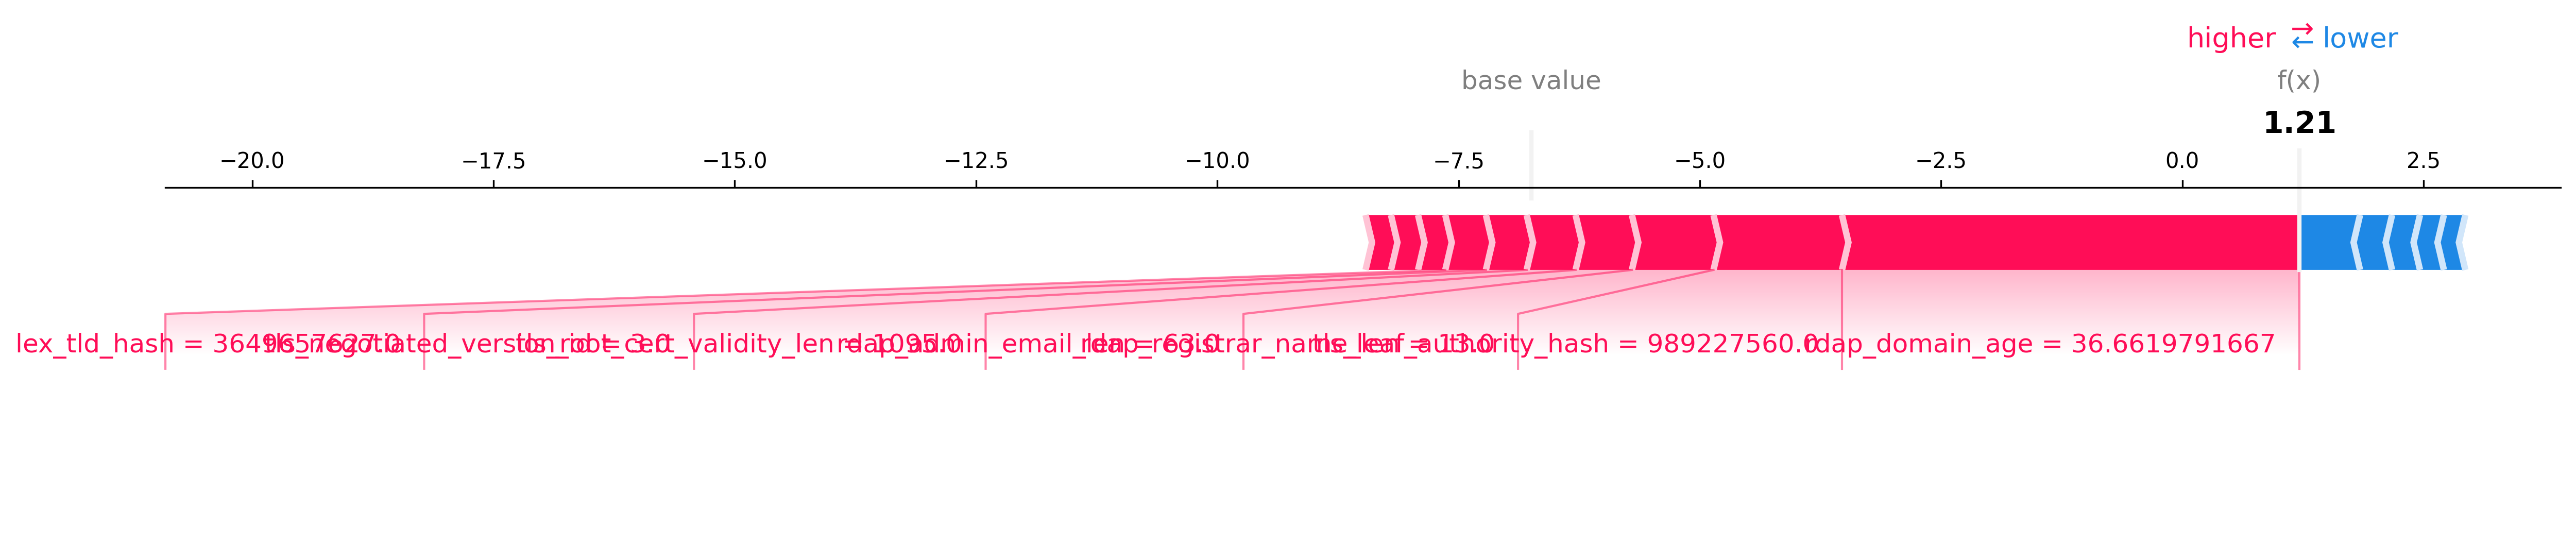


Domain: 123hdd.com


<Figure size 3600x900 with 0 Axes>

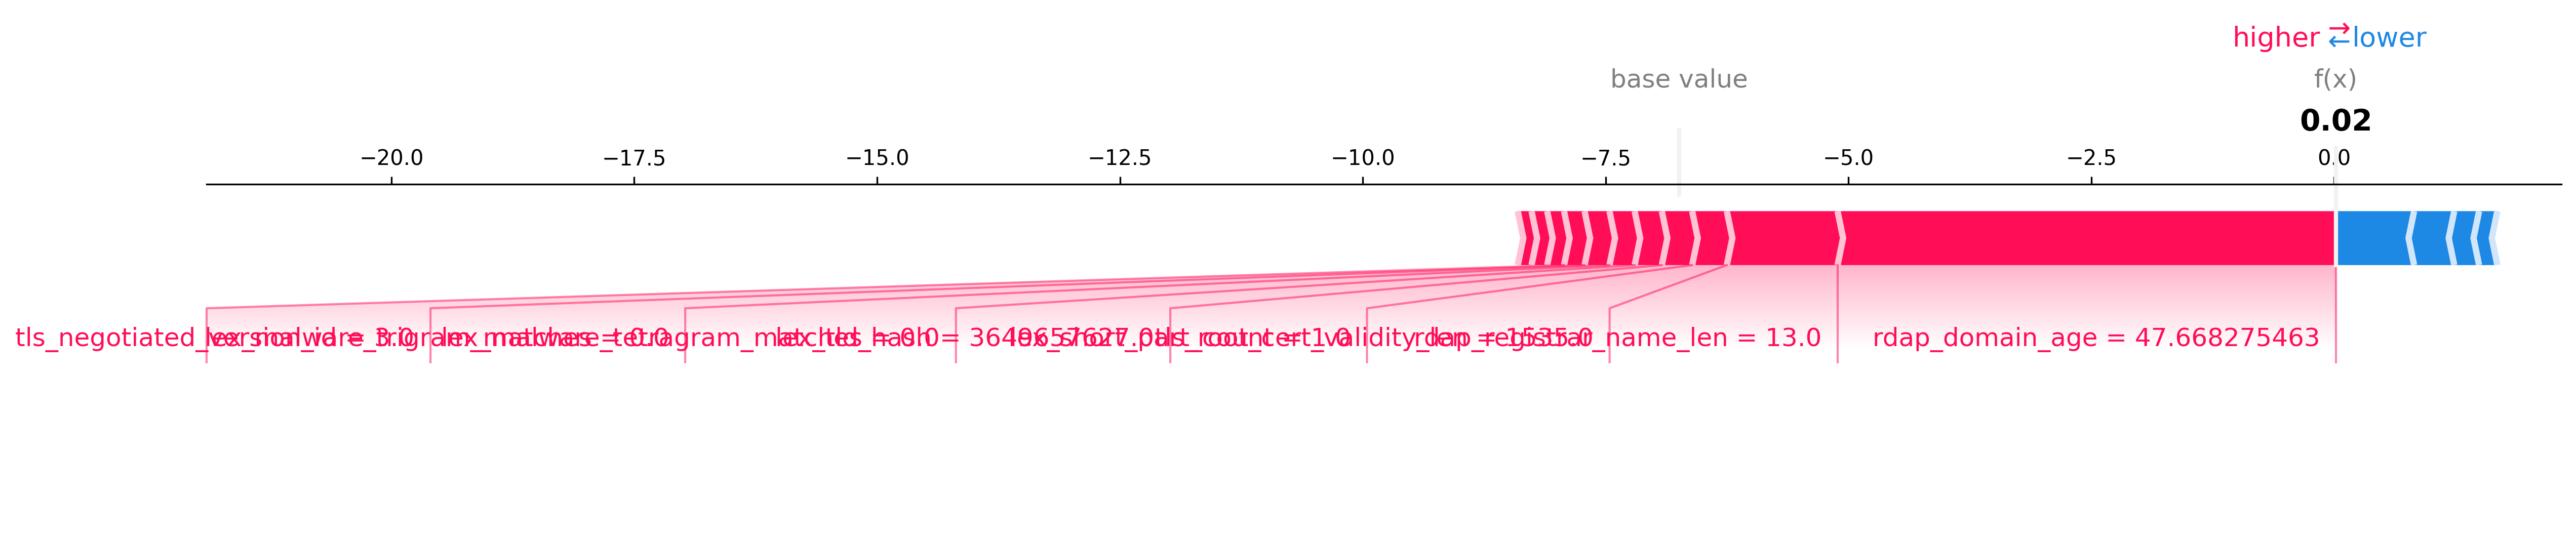


Domain: 123sss.net


<Figure size 3600x900 with 0 Axes>

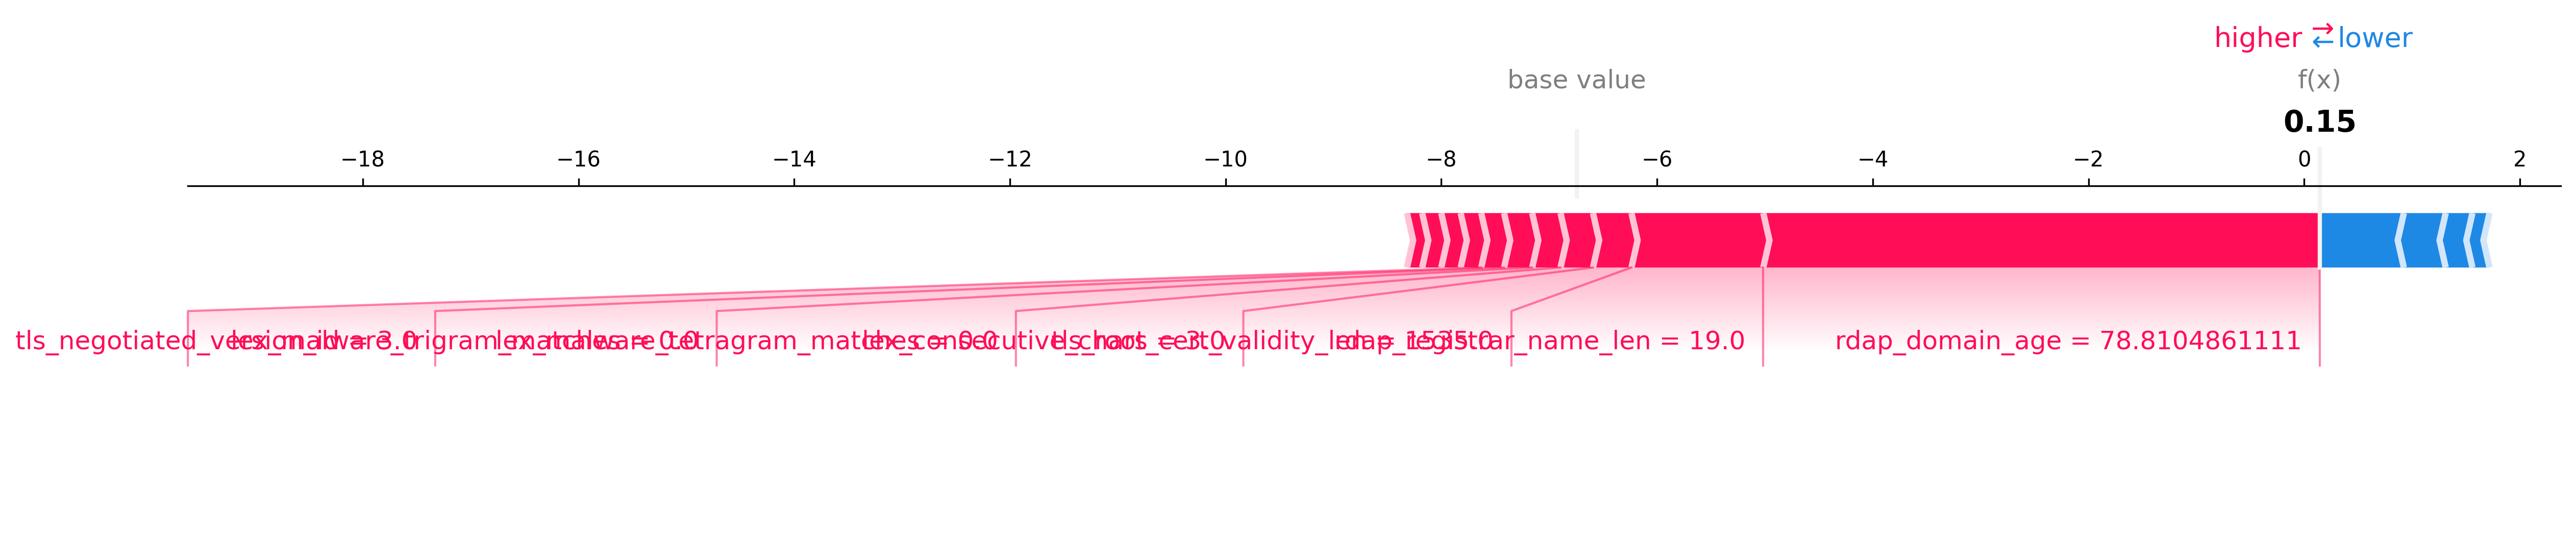


Domain: 14pg2.com


<Figure size 3600x900 with 0 Axes>

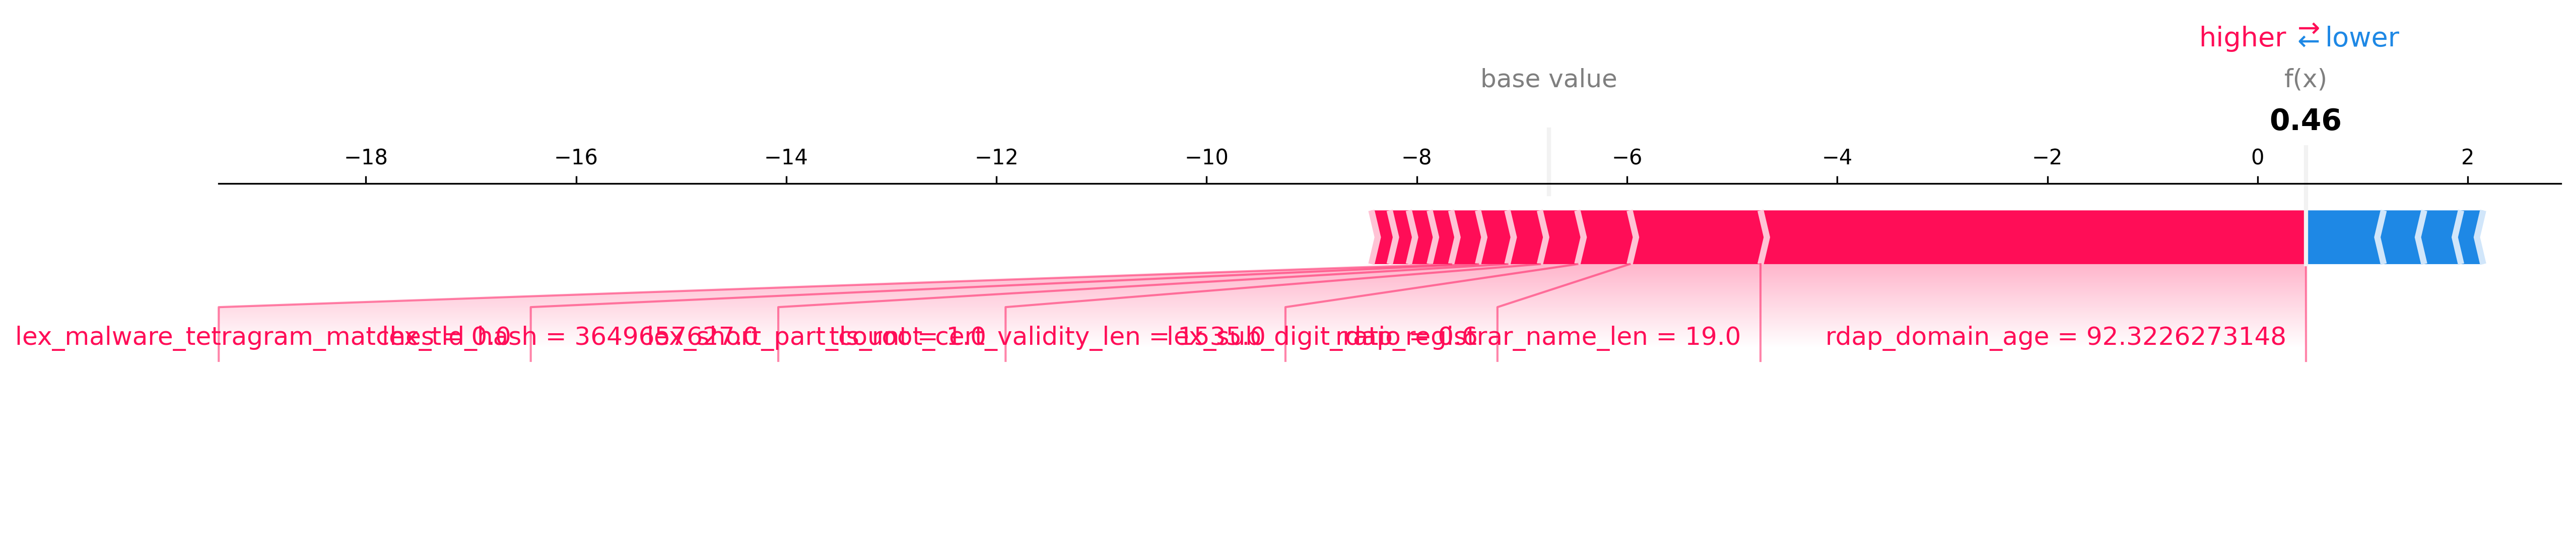


Domain: 14pg8.com


<Figure size 3600x900 with 0 Axes>

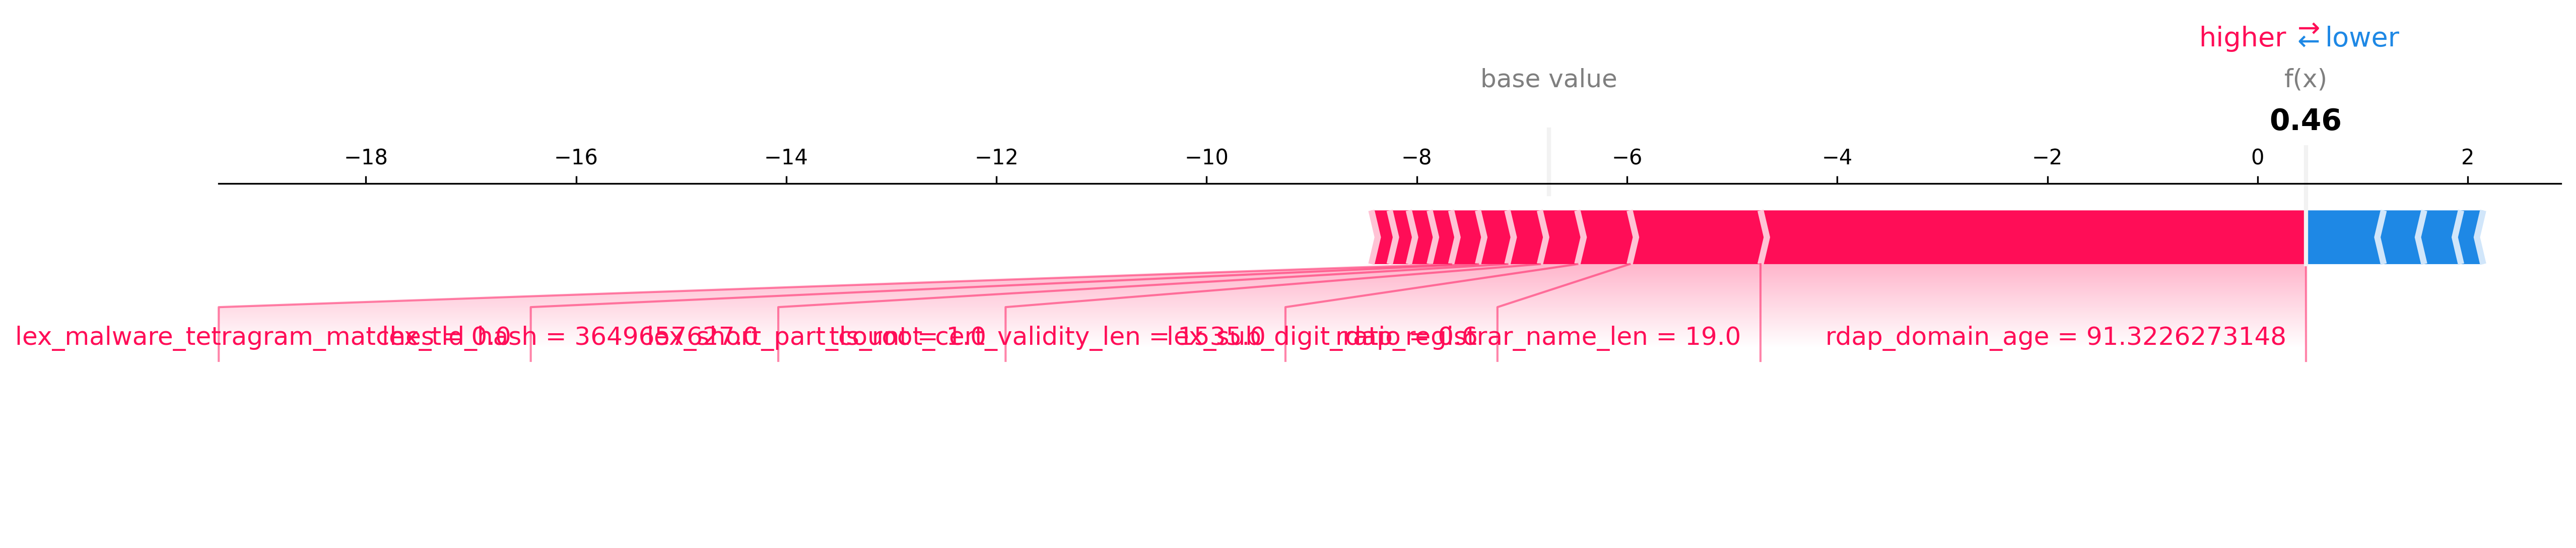


Domain: 1x7bet.xyz


<Figure size 3600x900 with 0 Axes>

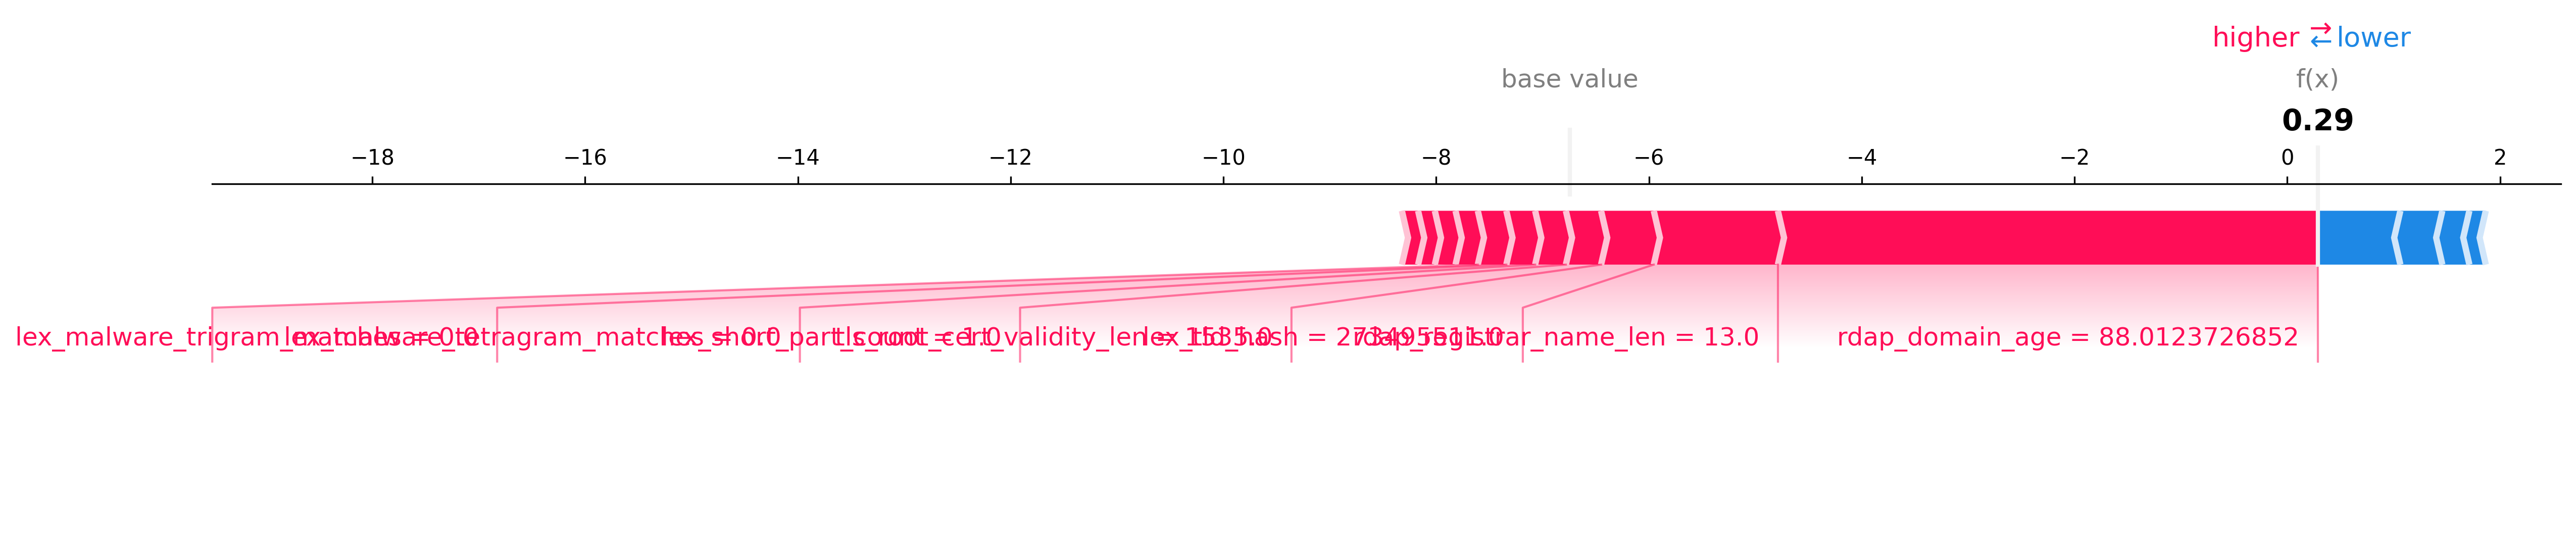


Domain: 2588989.com


<Figure size 3600x900 with 0 Axes>

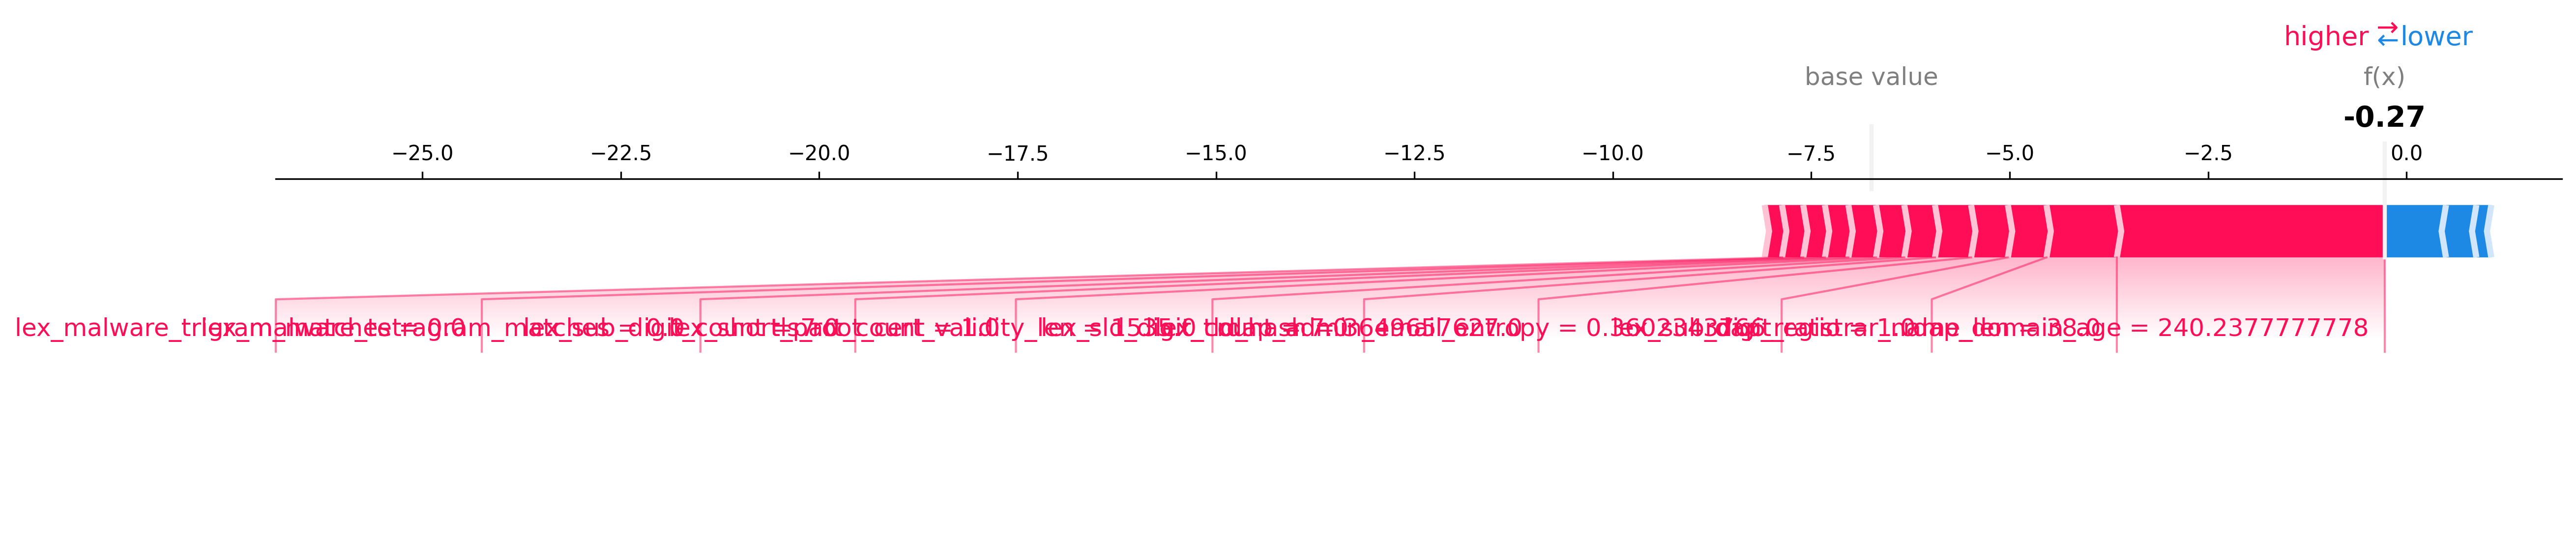


Domain: 2aksestukul.pro


<Figure size 3600x900 with 0 Axes>

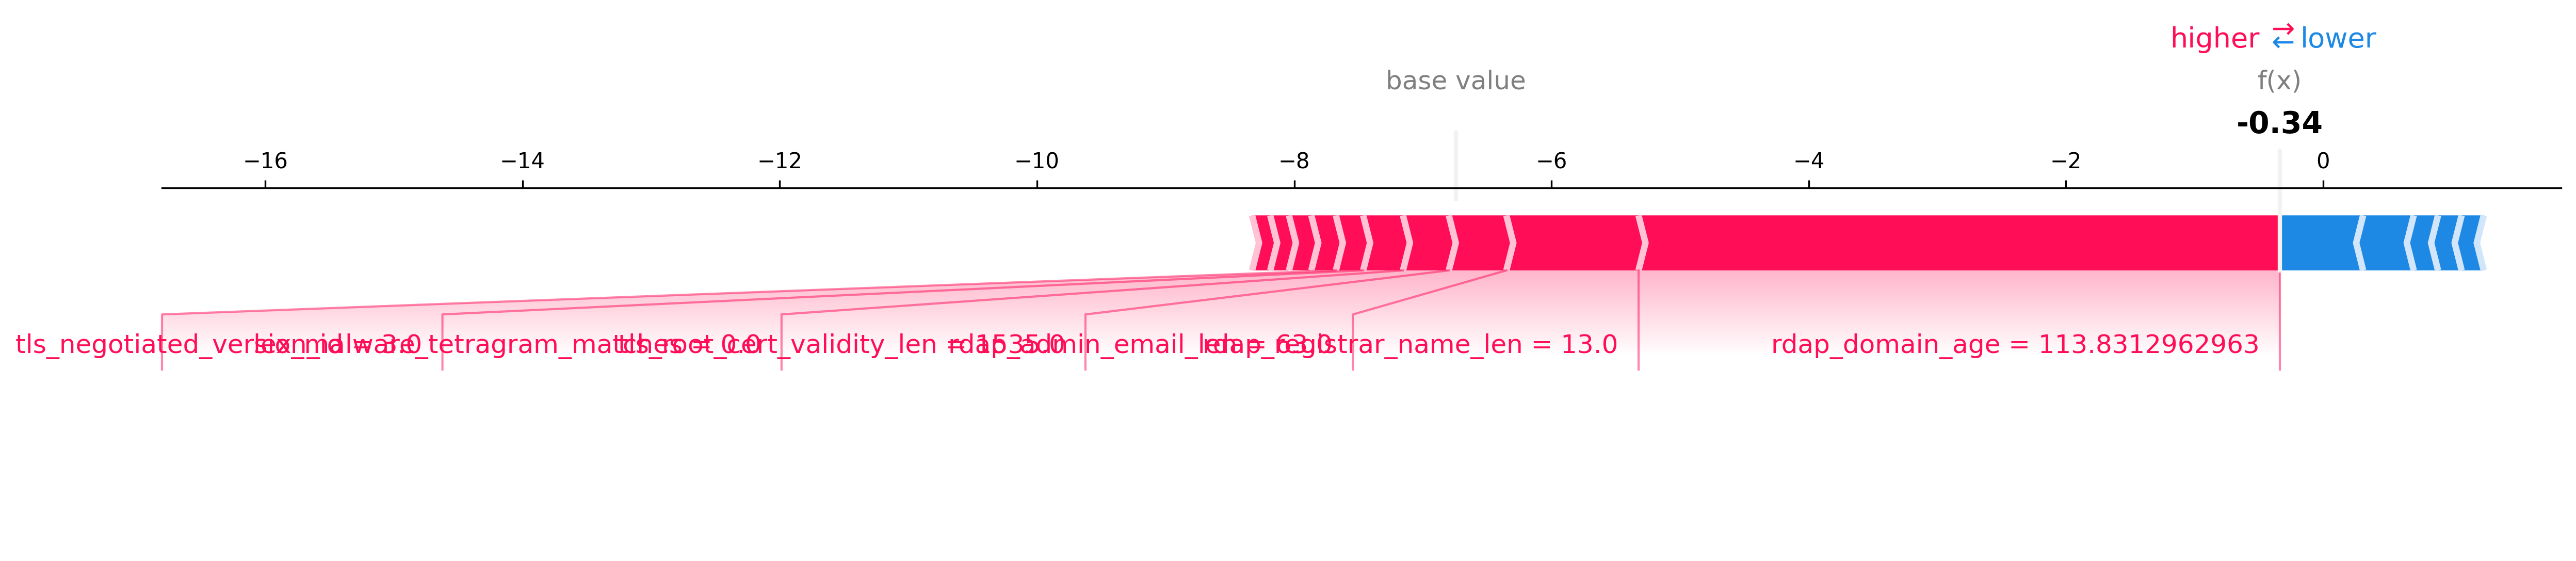


Domain: 42pg10.com


<Figure size 3600x900 with 0 Axes>

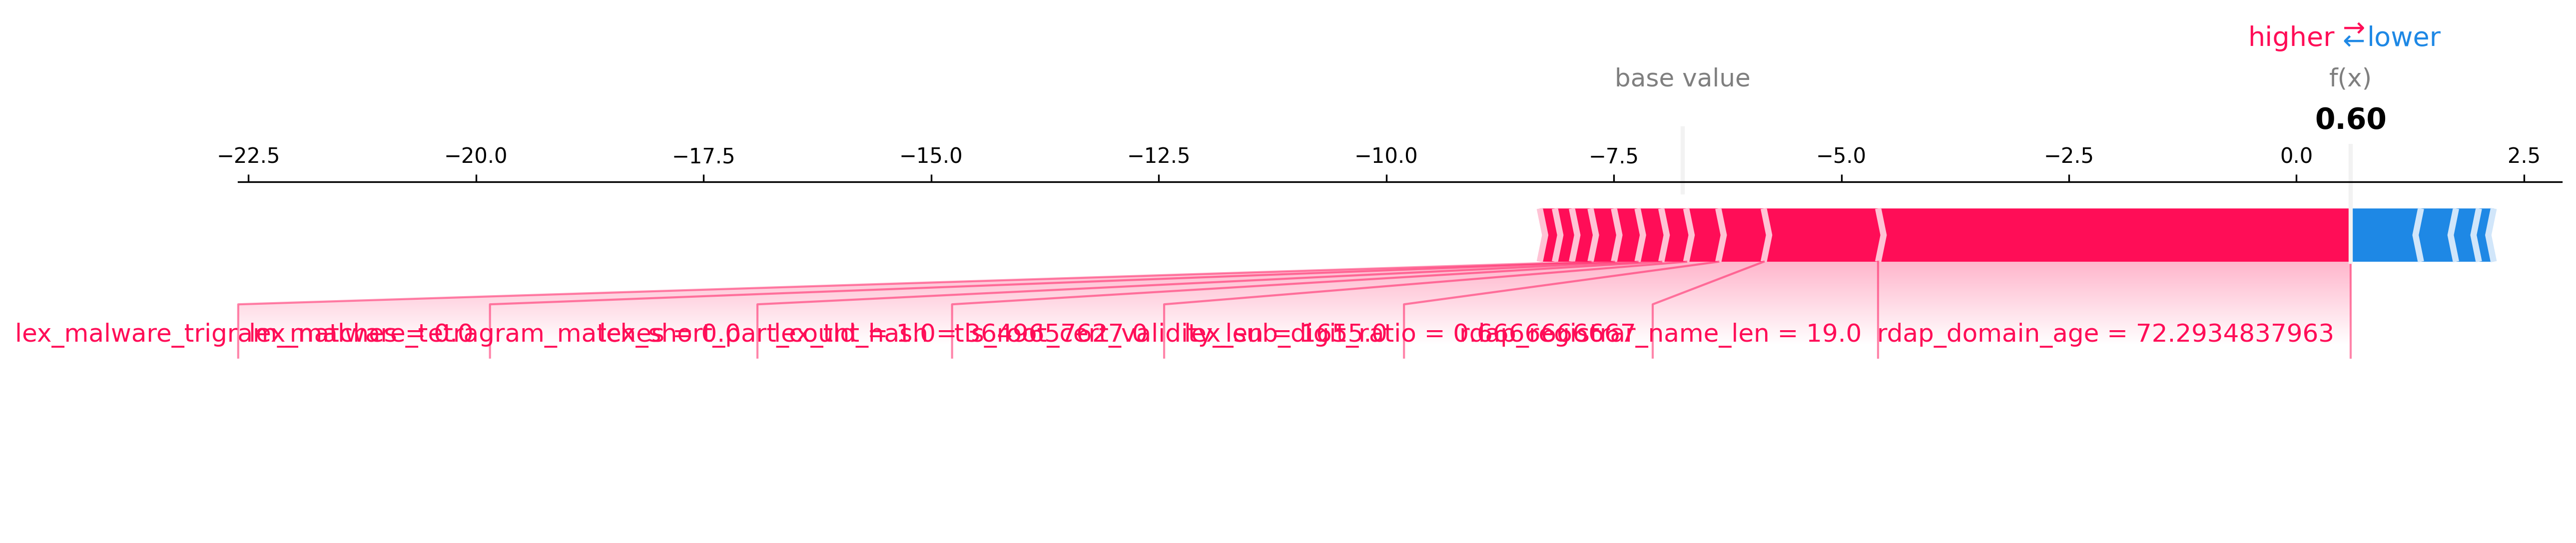


Domain: 53pgdd.com


<Figure size 3600x900 with 0 Axes>

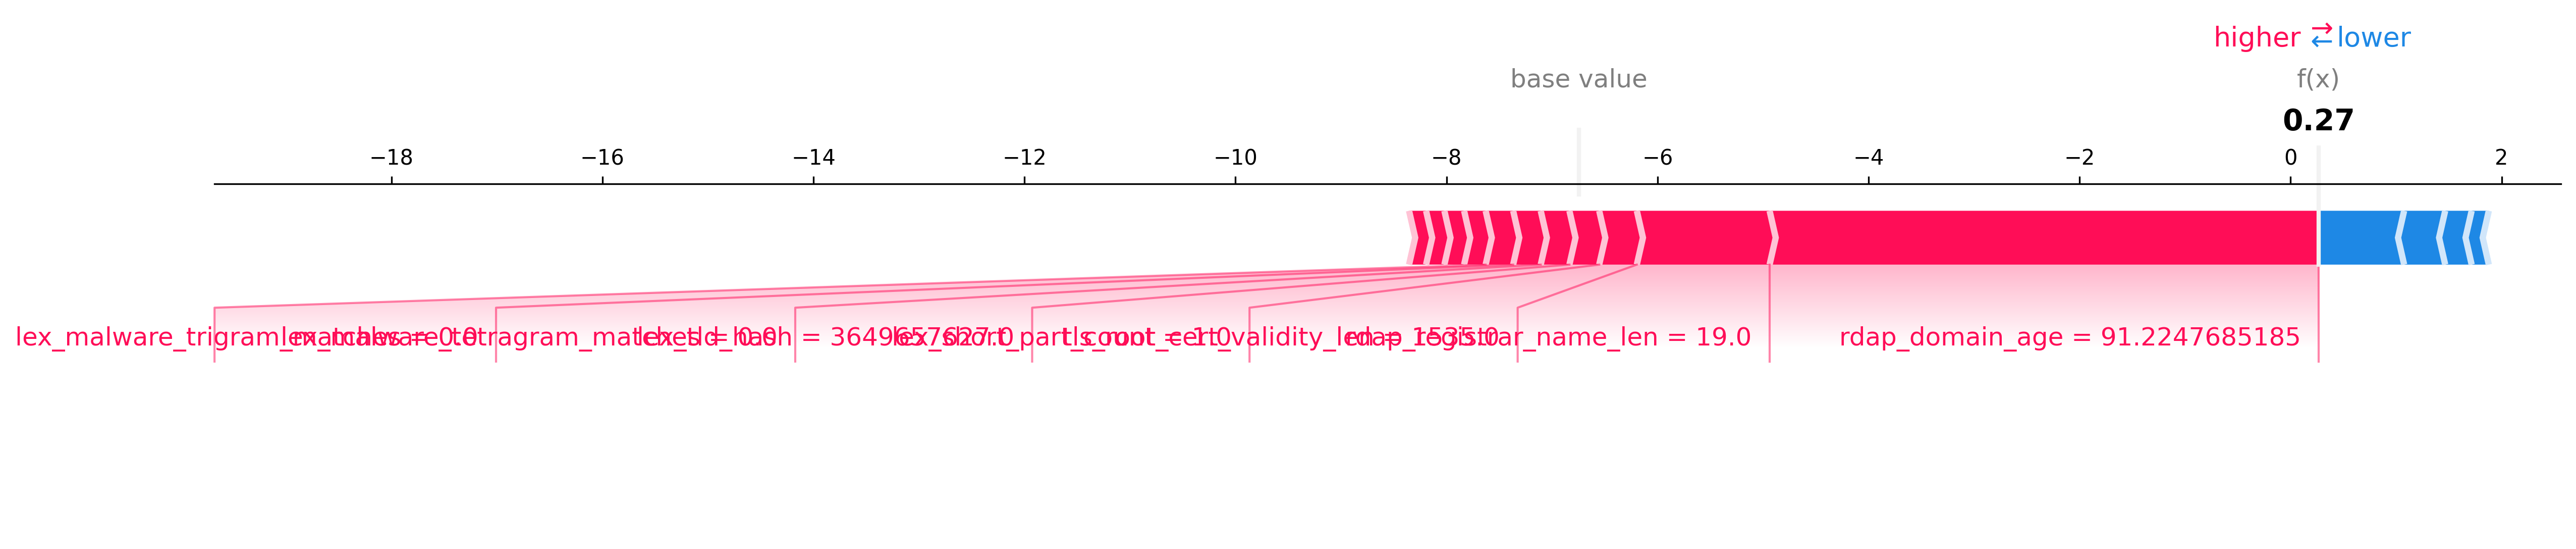


Domain: 5671602.xyz


<Figure size 3600x900 with 0 Axes>

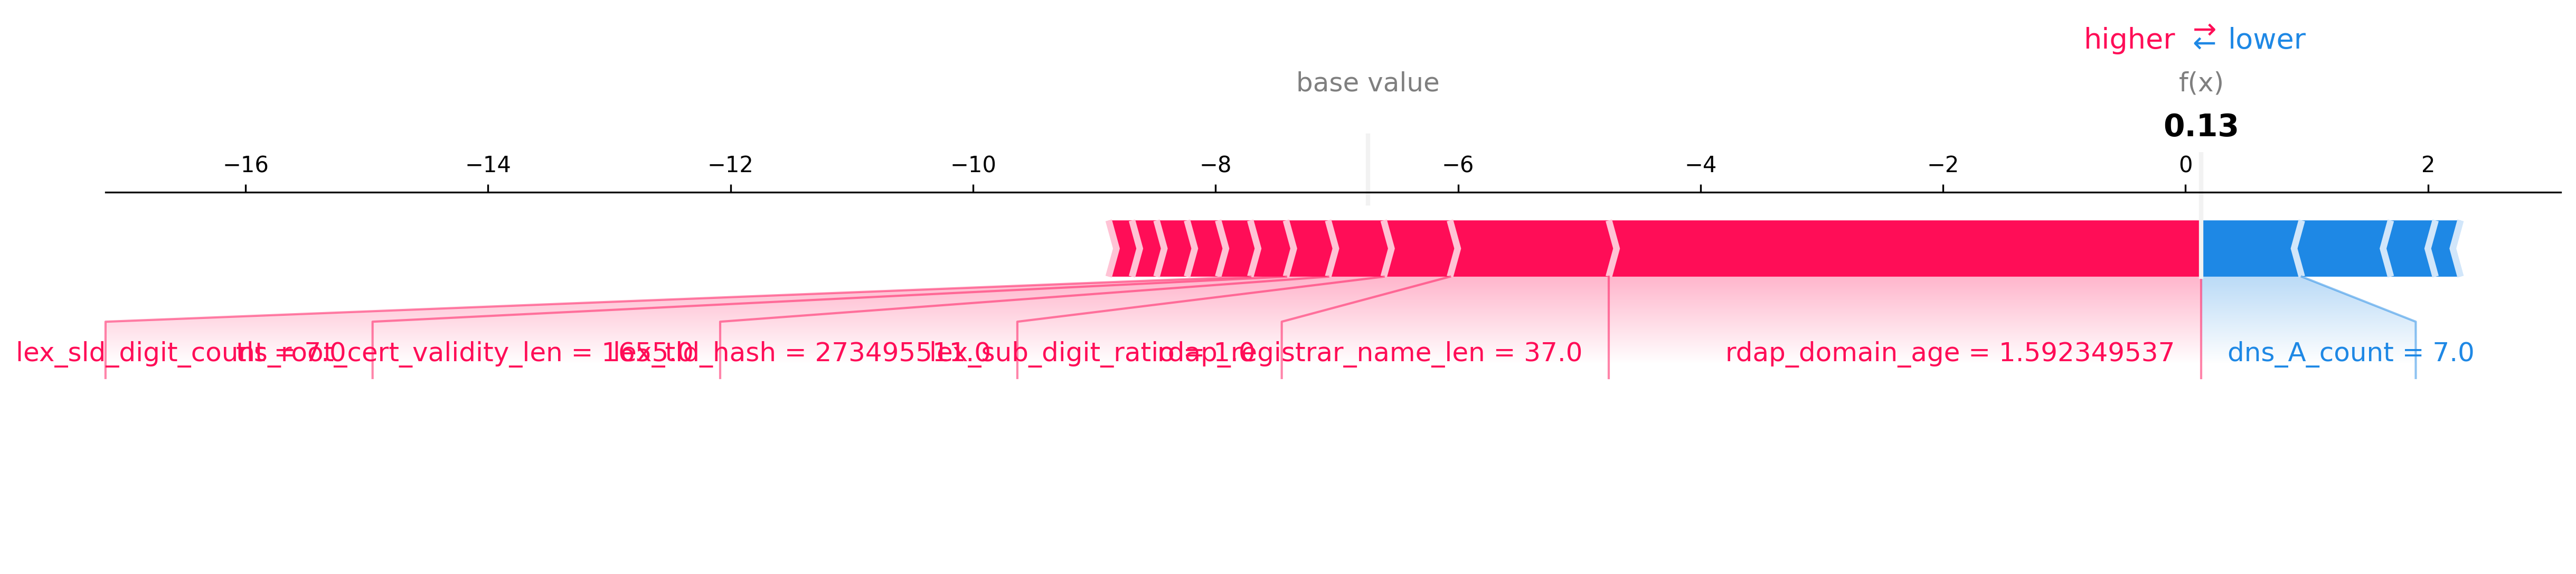


Domain: 599k11.com


<Figure size 3600x900 with 0 Axes>

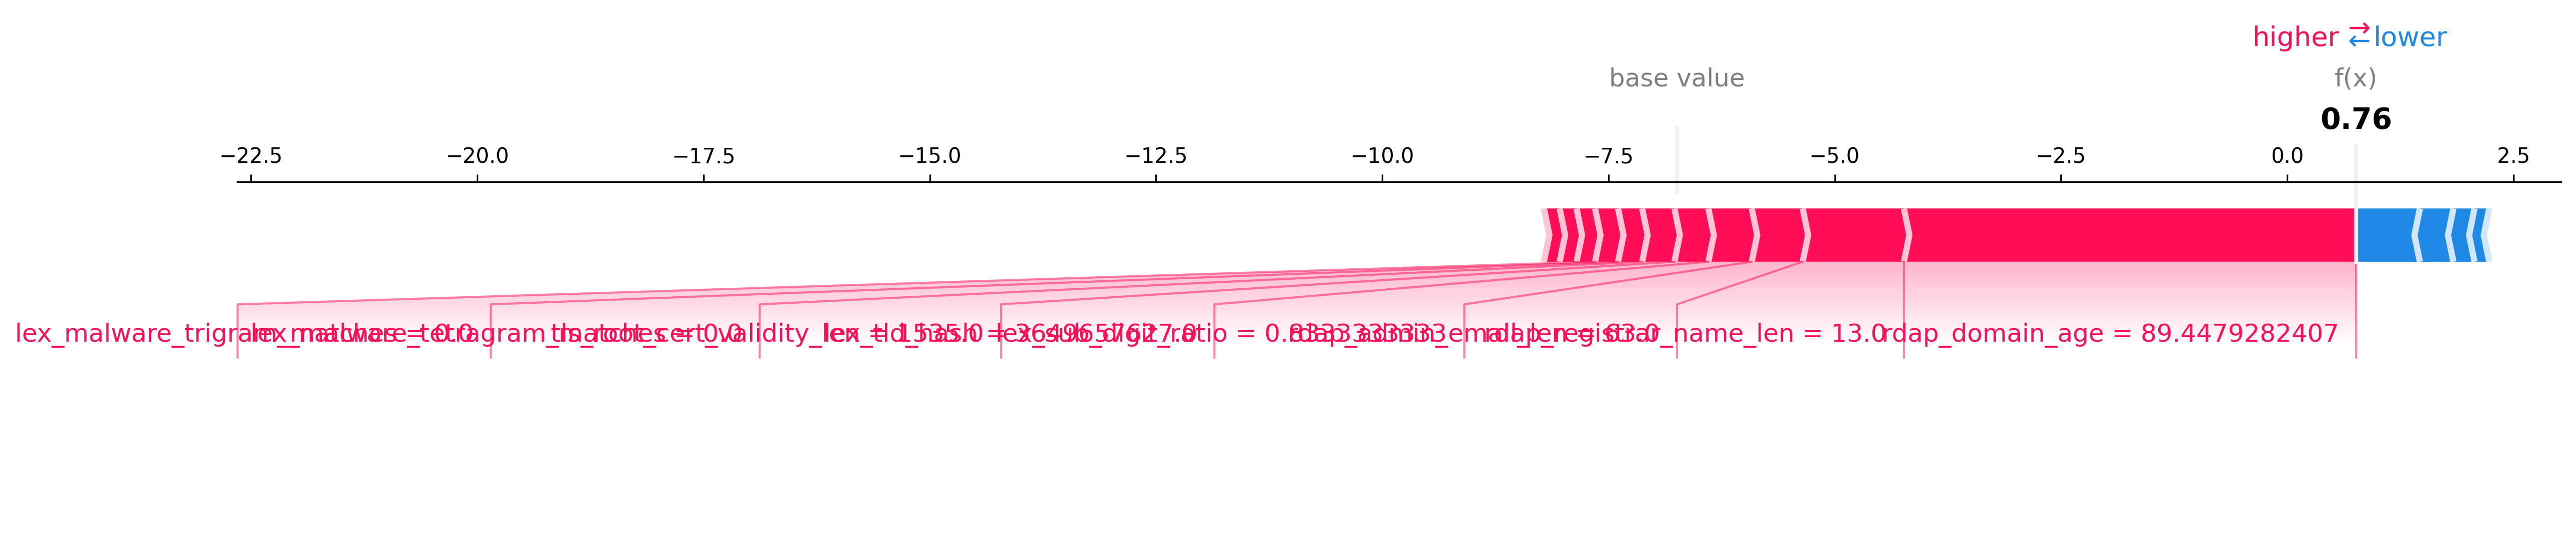


Domain: 66llottery.org


<Figure size 3600x900 with 0 Axes>

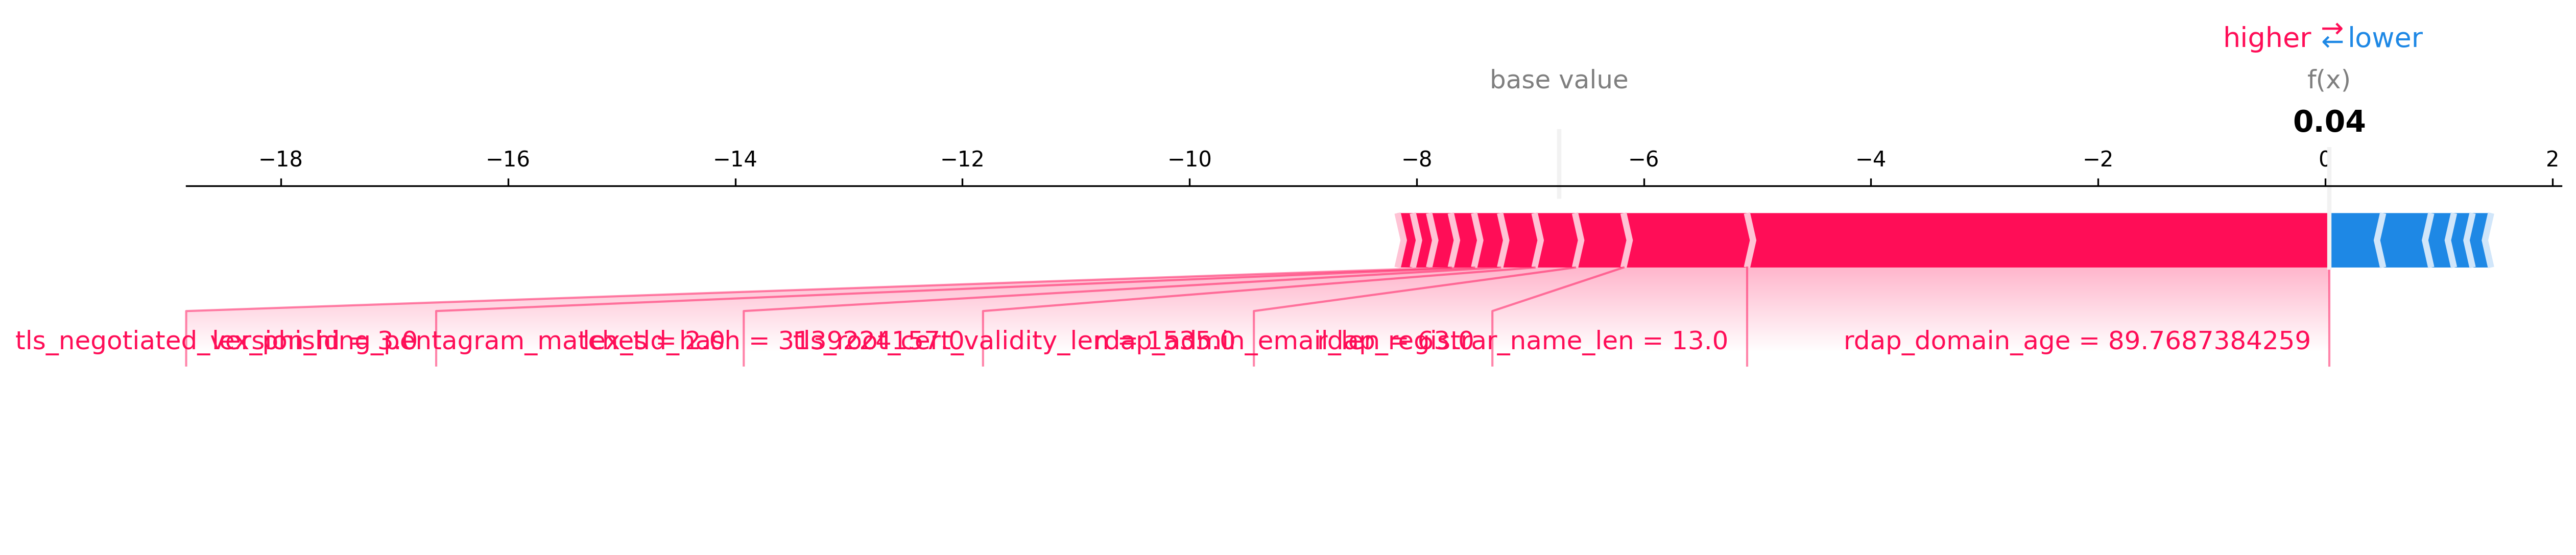


Domain: 66uba.com


<Figure size 3600x900 with 0 Axes>

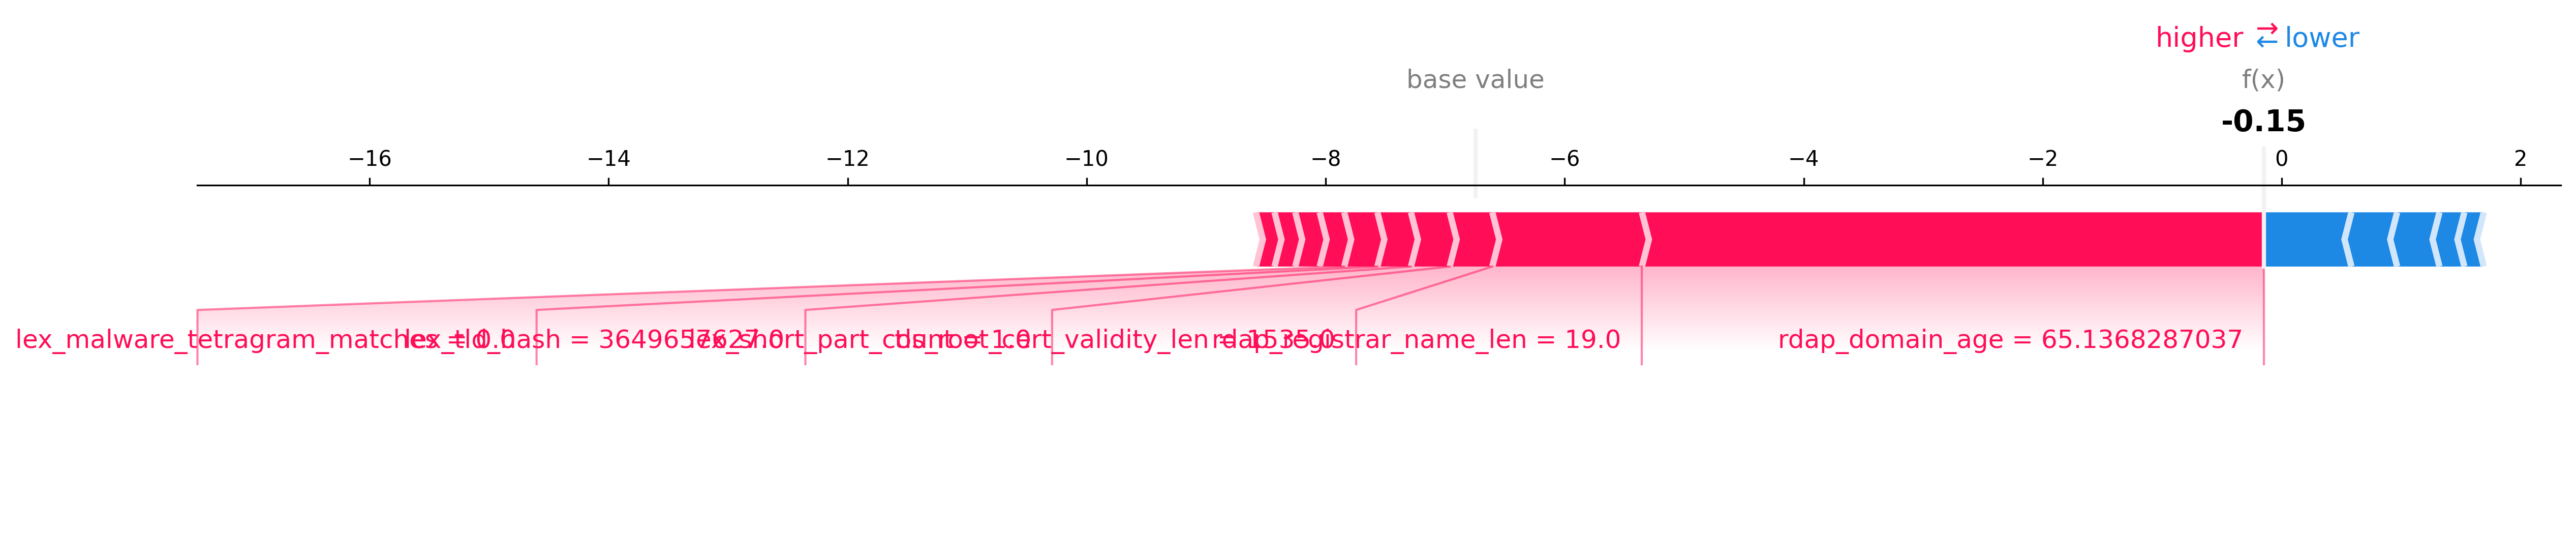


Domain: 72pgdd.com


<Figure size 3600x900 with 0 Axes>

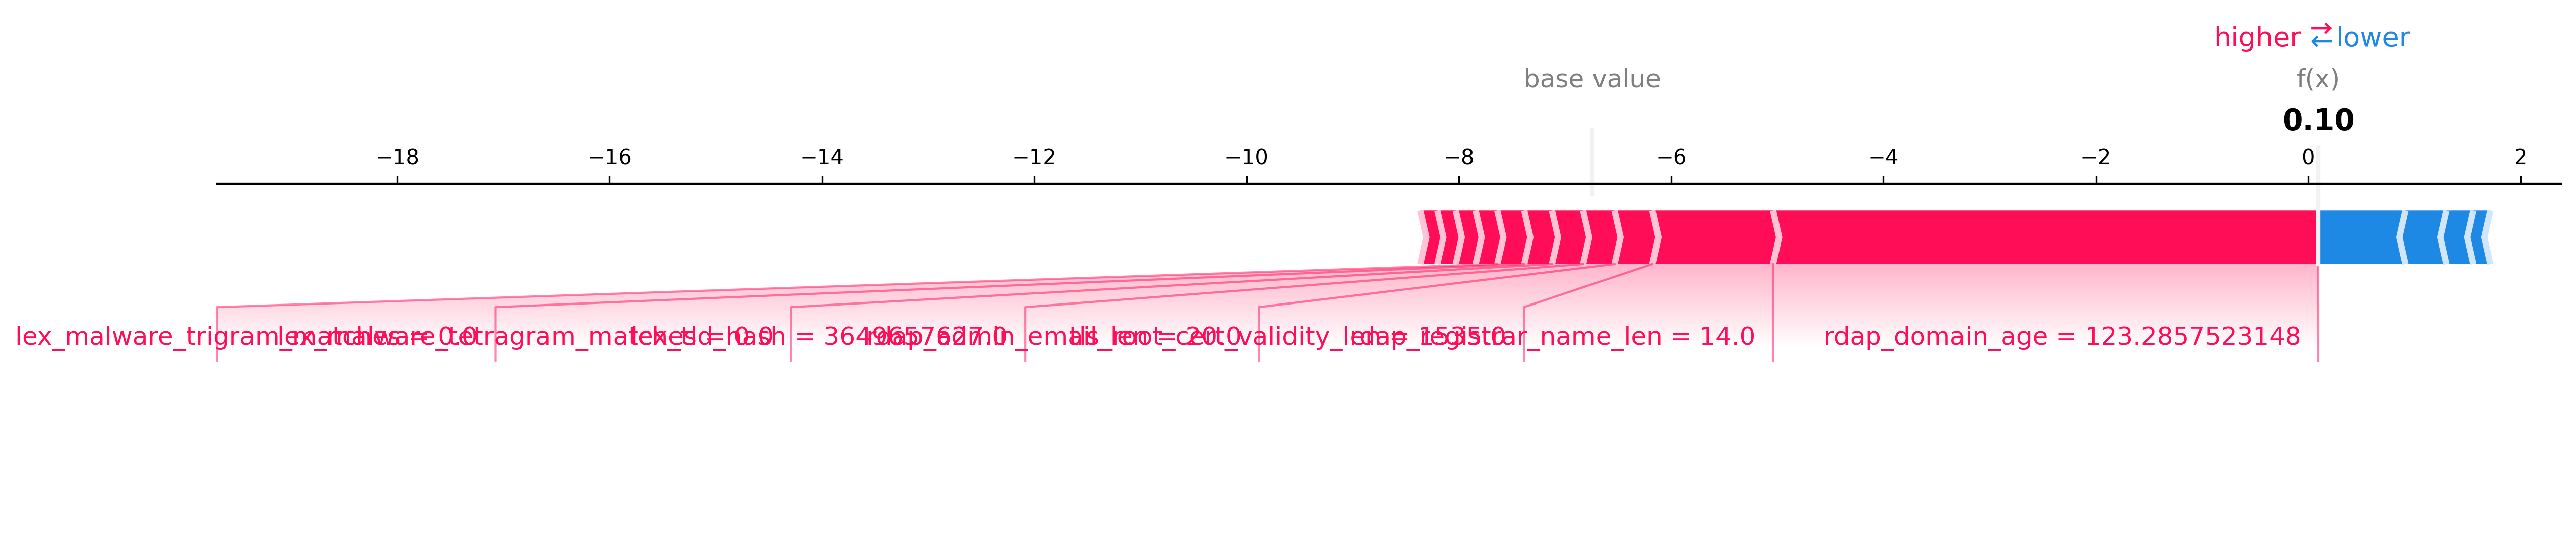


Domain: 777boijogo.com


<Figure size 3600x900 with 0 Axes>

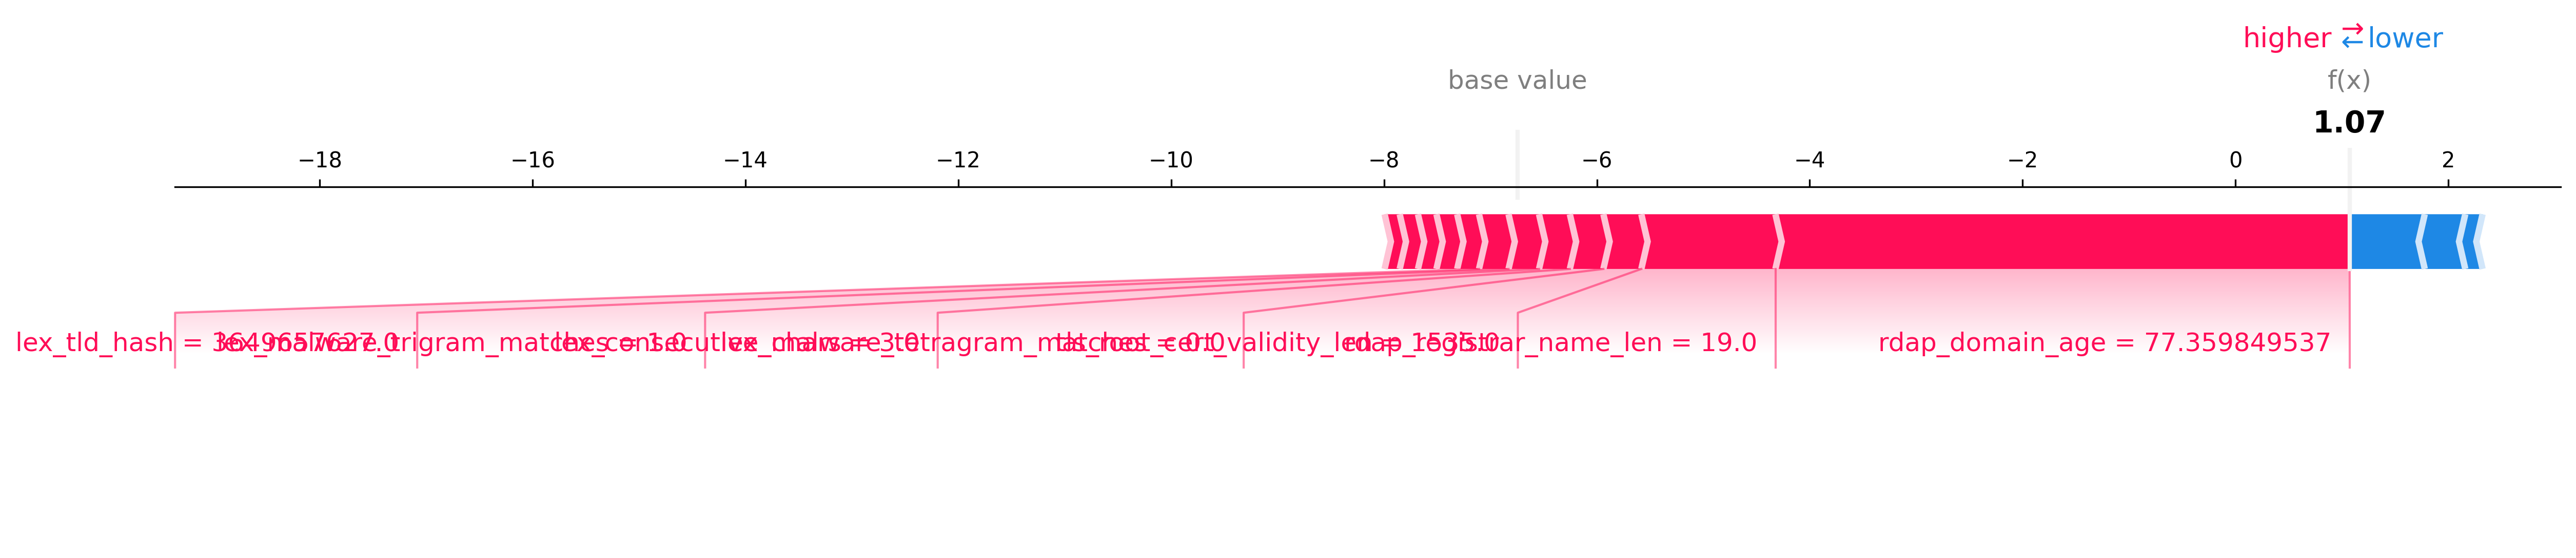


Domain: 95cemara777.com


<Figure size 3600x900 with 0 Axes>

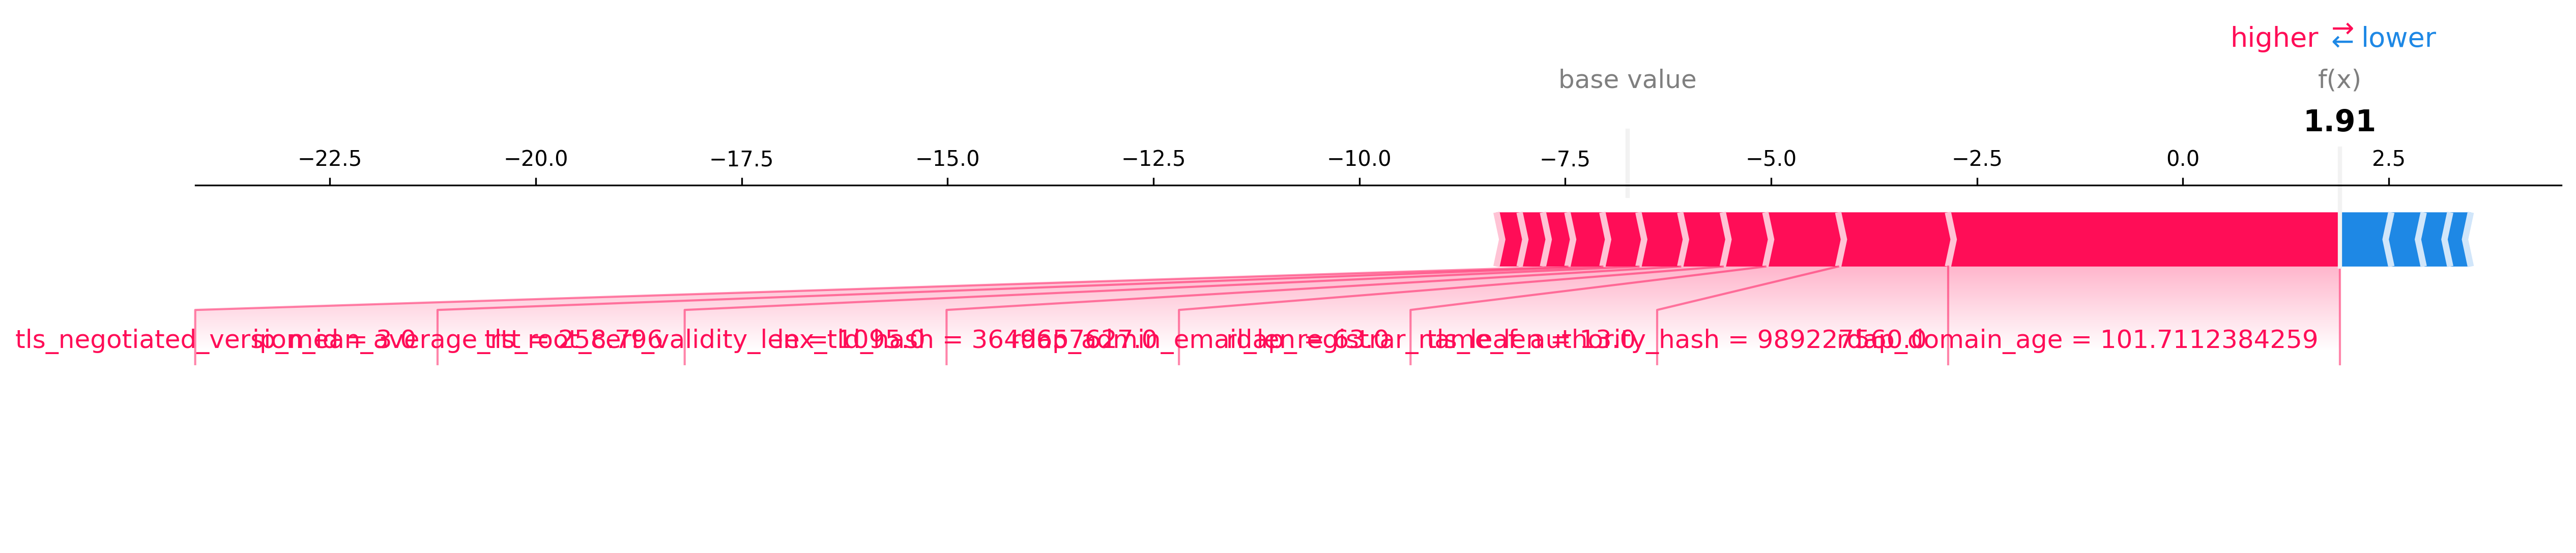


Domain: 99tg9e.com


<Figure size 3600x900 with 0 Axes>

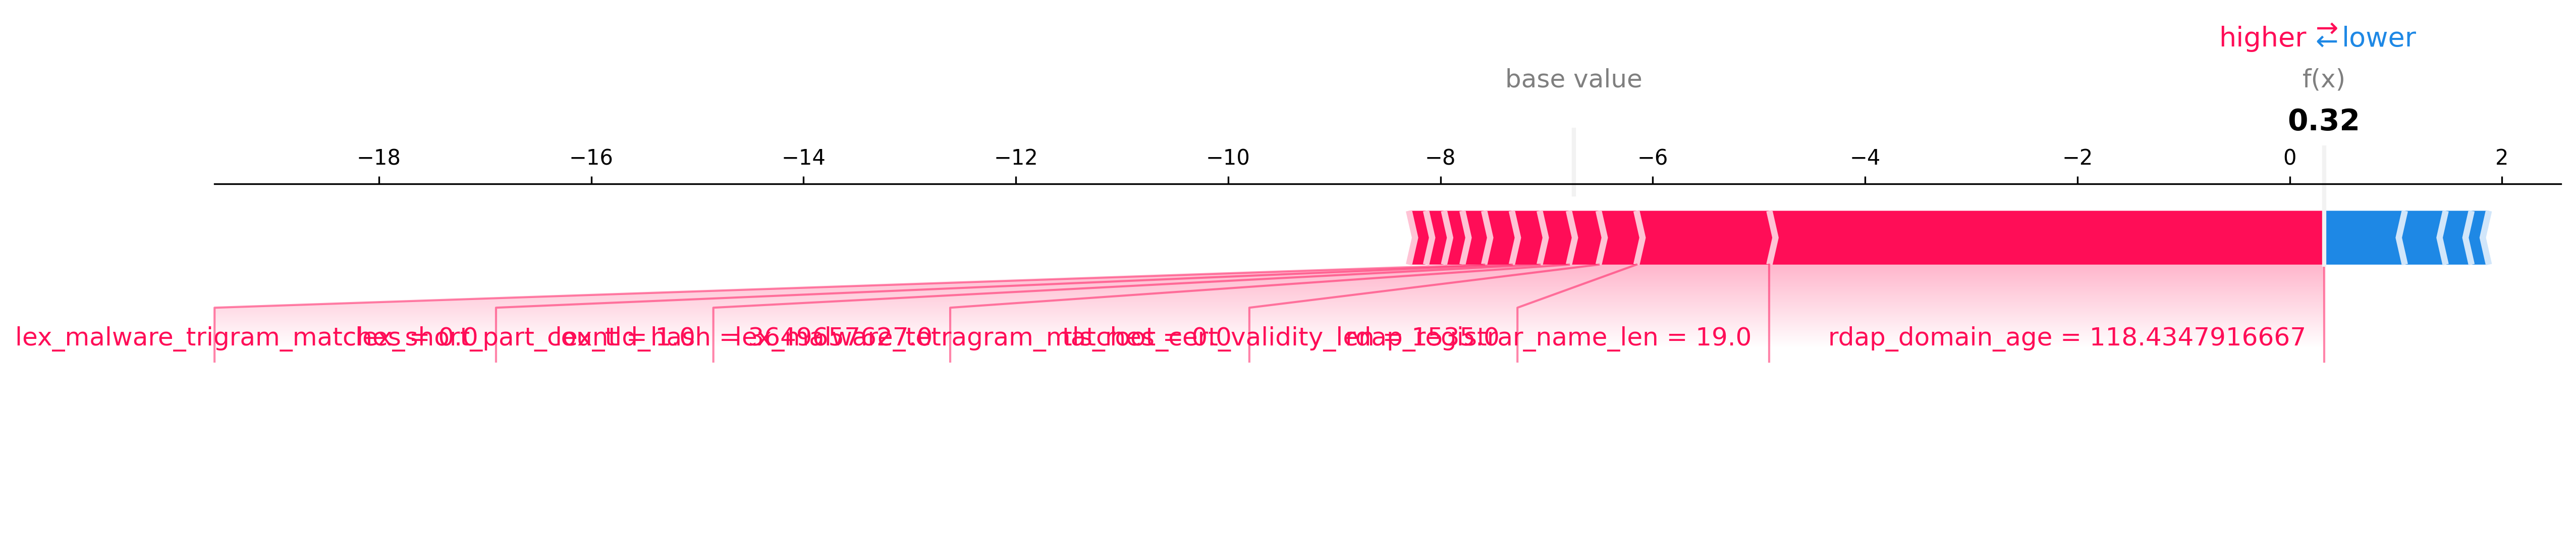


Domain: aa888.pw


<Figure size 3600x900 with 0 Axes>

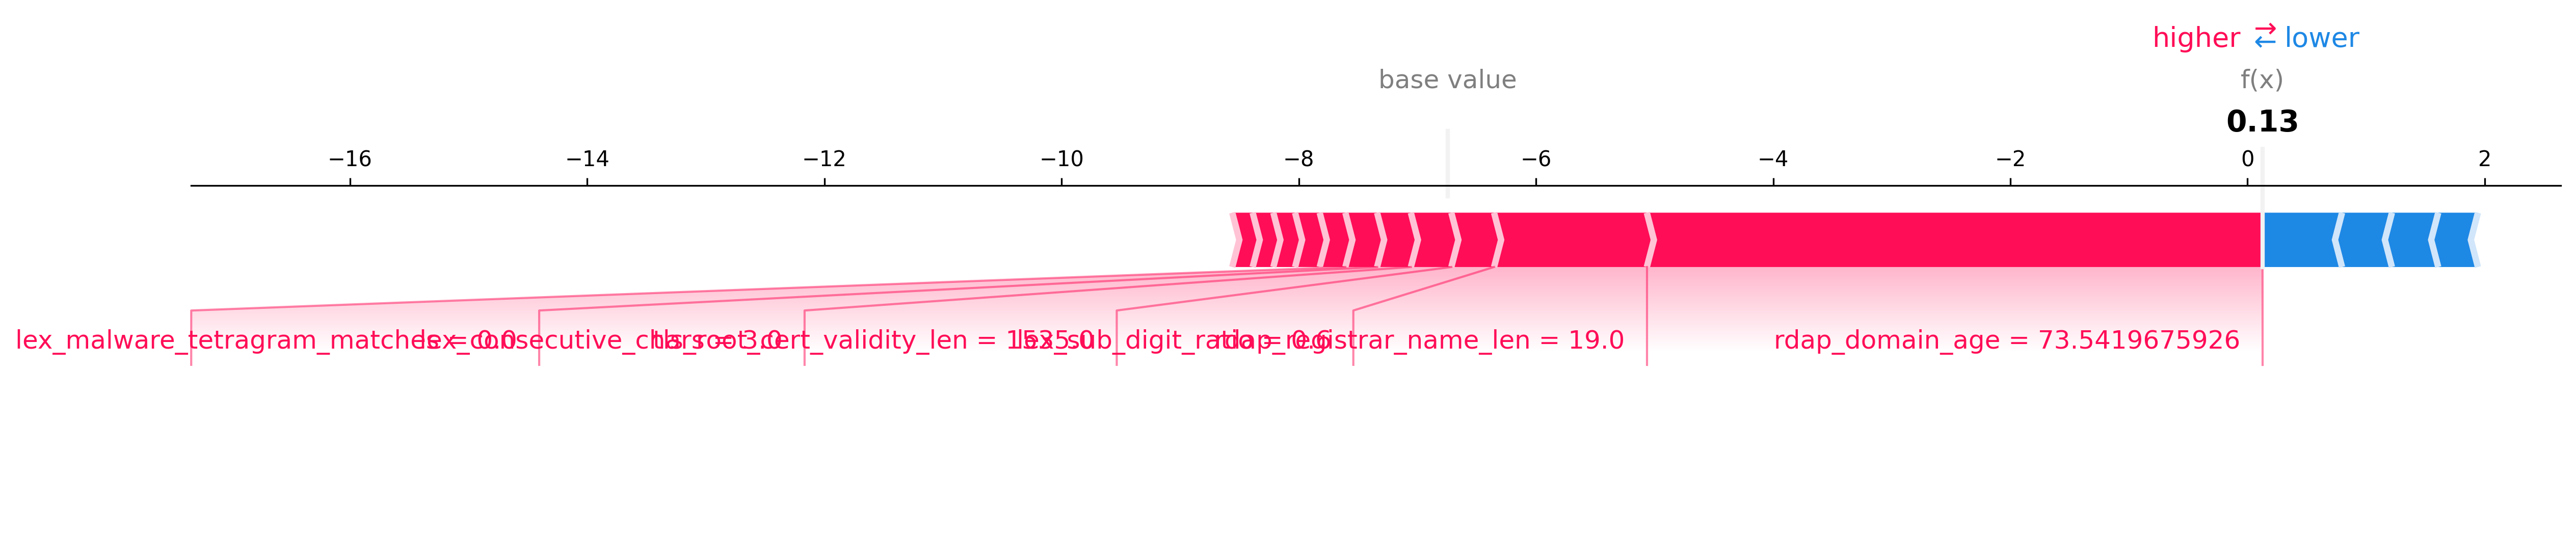


Domain: aceh4dterbaik.pro


<Figure size 3600x900 with 0 Axes>

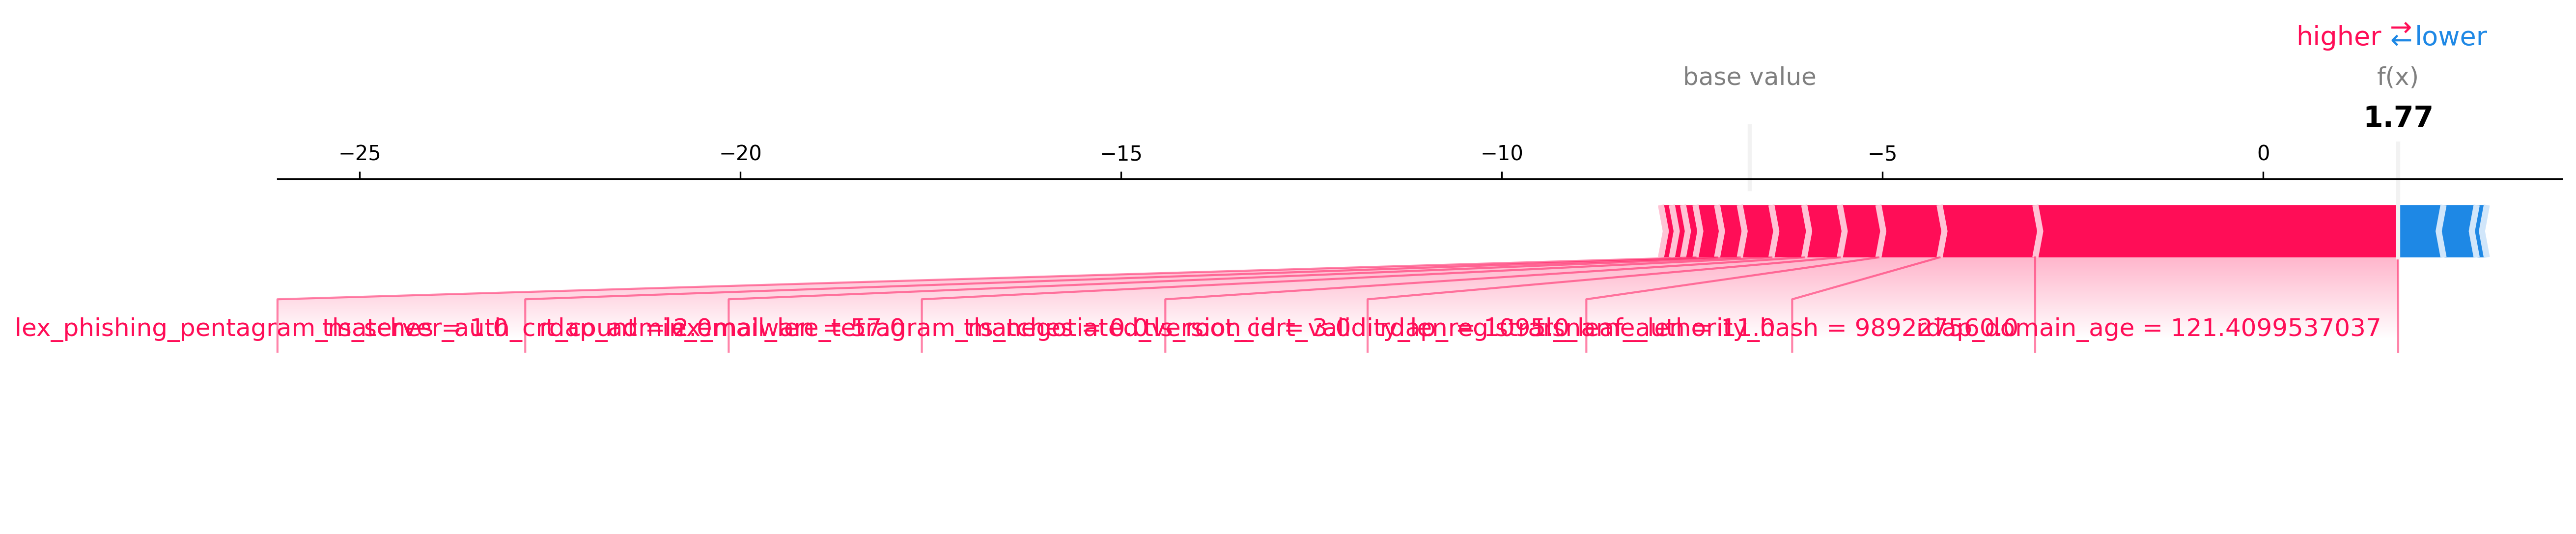

In [13]:
# ============================================
# Debug LightGBM classifier on a FP dataset
# ============================================
import warnings
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import shap
import joblib

from pandas.core.dtypes import common as com
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# --------- CONFIG ---------
fp_dataset = '../testdata/xyz.parquet'
correct_label = 'benign'          # the true label for this FP dataset
model_name = 'phishing_lgbm_model_nonndf'  # change if needed
# --------------------------

# ---------- helper functions ----------
def cast_timestamp(df: pd.DataFrame):
    """Cast timestamp fields to seconds since epoch."""
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9
    return df

def _get_model_feature_names_lgbm(model):
    """
    Try multiple ways to obtain the feature names from a trained LGBMClassifier (or a wrapped estimator).
    Compatible with sklearn API and native booster.
    """
    # 1) Native booster names
    try:
        if hasattr(model, "booster_") and model.booster_ is not None:
            fn = model.booster_.feature_name()
            if fn is not None and len(fn) > 0:
                return list(fn)
    except Exception:
        pass

    # 2) Sklearn attributes
    for attr in ("feature_name_", "feature_names_in_"):
        if hasattr(model, attr):
            try:
                fn = getattr(model, attr)
                if fn is not None and len(fn) > 0:
                    return list(fn)
            except Exception:
                pass

    # 3) If model is inside a Pipeline
    if hasattr(model, "steps"):
        try:
            return _get_model_feature_names_lgbm(model.steps[-1][1])
        except Exception:
            pass

    return None

def _align_features(X: pd.DataFrame, required: list, fill_value=-1.0) -> pd.DataFrame:
    X = X.copy()
    if required is None:
        return (X.replace([np.inf, -np.inf], np.nan).fillna(fill_value))
    for f in required:
        if f not in X.columns:
            X[f] = fill_value
    X = X[[f for f in required]]
    X = (X.replace([np.inf, -np.inf], np.nan).fillna(fill_value))
    return X

def display_shap_for_misclassified_lgbm(model, misclassified_df: pd.DataFrame, top_n=10, positive_class=1, top_k_features=15):
    """Render SHAP force plots for the first N misclassified domains (top-k features only)."""
    if misclassified_df.empty:
        print("No misclassified samples provided.")
        return

    subset = misclassified_df.head(top_n).copy()
    X = subset.drop(columns=[c for c in ['label', 'domain_name'] if c in subset.columns])

    req = _get_model_feature_names_lgbm(model)
    X = _align_features(X, req, fill_value=-1.0)

    # SHAP explainer for LightGBM
    try:
        explainer = shap.TreeExplainer(model)  # works for LGBMClassifier
    except Exception:
        warnings.warn("TreeExplainer failed; using generic shap.Explainer.", RuntimeWarning)
        explainer = shap.Explainer(model, X, feature_names=list(X.columns))

    shap_values = explainer.shap_values(X)

    # LightGBM binary: shap_values can be a list [class0, class1] in some versions
    if isinstance(shap_values, list):
        sv = shap_values[positive_class]
        expected_value = explainer.expected_value[positive_class]
    else:
        sv = shap_values
        expected_value = explainer.expected_value

    shap.initjs()

    for i in range(len(subset)):
        domain = subset.iloc[i]['domain_name'] if 'domain_name' in subset.columns else f"idx {i}"
        print(f"\nDomain: {domain}")

        # pick top-k features by absolute shap value
        vals = sv[i]
        feature_names = np.array(X.columns)
        top_idx = np.argsort(np.abs(vals))[-top_k_features:]
        top_features = feature_names[top_idx]
        top_vals = vals[top_idx]
        top_sample = X.iloc[i, top_idx]

        plt.figure(figsize=(12, 3))
        shap.force_plot(expected_value, top_vals, top_sample, matplotlib=True, show=True)

# ---------- main evaluation pipeline ----------
# Load the FP dataset
df_validation = pq.read_table(fp_dataset).to_pandas()
df_validation["label"] = correct_label

# Drop columns starting with "html_" (mirrors your XGB script)
df_validation = df_validation.drop(columns=[c for c in df_validation.columns if c.startswith("html_")], errors='ignore')

# Cast timestamps and handle NaNs
df_validation = cast_timestamp(df_validation)
df_validation.fillna(-1, inplace=True)

# Remove disqualified columns (if defined upstream)
try:
    disqualified_columns
except NameError:
    disqualified_columns = []

for column in disqualified_columns:
    if column in df_validation.columns:
        df_validation.drop(column, axis=1, inplace=True)

# Map the labels
df_validation['label'] = df_validation['label'].map({'benign': 0, 'phishing': 1})

# Extract features and labels
X_val = df_validation.drop(columns=[c for c in ['label', 'domain_name'] if c in df_validation.columns], errors='ignore')
y_val = df_validation['label']

# Load the trained LightGBM model
model = joblib.load('models/' + model_name + '.joblib')

# Align features
required_features = _get_model_feature_names_lgbm(model)
if required_features is not None:
    X_val = _align_features(X_val, required_features, fill_value=-1.0)
else:
    warnings.warn("Could not determine model feature names automatically; proceeding without reordering.", RuntimeWarning)

# Make predictions
y_pred = model.predict(X_val)
# Some LGBM setups may have objective/binary without predict_proba;
# but if available, this returns shape (n_samples, 2)
if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_val)[:, 1]
else:
    # fallback: decision_function or raw_score to sigmoid if needed
    try:
        raw = model.predict(X_val, raw_score=True)
        # apply sigmoid
        y_prob = 1.0 / (1.0 + np.exp(-raw))
    except Exception:
        y_prob = None

# Metrics
accuracy = accuracy_score(y_val, y_pred)
weighted_accuracy = (accuracy_score(y_val[y_val == 0], y_pred[y_val == 0]) +
                     accuracy_score(y_val[y_val == 1], y_pred[y_val == 1])) / 2
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f'Accuracy: {accuracy}')
print(f'Weighted Accuracy: {weighted_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'False Positive Rate: {false_positive_rate}')

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Misclassified domains
misclassified = df_validation[y_val != y_pred]
misclassified_domains = misclassified['domain_name'].tolist() if 'domain_name' in misclassified.columns else []
print(f'Misclassified domains: {misclassified_domains}')

# SHAP force plots for first N misclassified samples
display_shap_for_misclassified_lgbm(model, misclassified, top_n=20)
